# E11 · Scientific machine learning: a neural network inside a differential equation

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Hudson's Bay Company pelt records 1900-1920: snowshoe hare and Canadian lynx, thousands of pelts per year (the data of E09) |
| **You will learn** | Universal differential equations: known physics plus a neural network for the term you do not know · a network as a pure JAX function of one flat weight vector that PyMC owns · why a from-scratch Bayesian neural ODE defeats NUTS, measured · putting the physics in the *prior* instead · prior predictive checks in function space · why $\hat{R}$ on weights is meaningless and what to check instead · ADVI and Pathfinder against NUTS in function space · reading the learned mechanism with credible bands · LOO versus a real forecast for three models, from fully mechanistic to black box |

E09 fitted the Lotka-Volterra equations to the lynx and hare records. That model *assumes*
the form of the interaction: hares are eaten at a rate proportional to hares times lynx
("mass action"). What if you do not trust that term? The idea behind **universal
differential equations** (Rackauckas et al. 2020) is to keep the terms you trust and let a
small neural network stand in for the one you do not. **Bayesian neural ODEs** (Dandekar
et al. 2020) add the obvious next step: be Bayesian about the network weights as well as
the physical parameters, so that the discovered mechanism comes with uncertainty instead
of being a point fit. The plain neural ODE, $\dot z = \text{NN}(z)$ with no physics at all, is
Chen et al. (2018).

This notebook builds all three points of that spectrum on 21 years of data, and it is
frank about what happened. The short version: the textbook hybrid (a network learning the
interaction from scratch) is easy to *optimise* and close to impossible to *sample* in the
time budget of this notebook; a reformulation that puts the physics into the prior samples
cleanly in under a minute; and when the models are asked to forecast six years they have
not seen, every bit of flexibility costs accuracy. It assumes you have read E09: the
`wrap_jax` route, the RK4 `lax.scan` solver, the log-scale state and the advice on starting
values are used here without being re-taught.

In [1]:
import time
import warnings

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import pymc as pm
import pymc_extras as pmx
import pytensor
import pytensor.tensor as pt
import scipy.optimize
import xarray as xr
from jax.flatten_util import ravel_pytree
from jax.scipy import stats as jstats
from pytensor.gradient import verify_grad
from scipy.special import logsumexp

from pymc_challenges import data

# JAX defaults to float32. PyMC works in float64. Set this BEFORE creating any JAX array.
jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="Numba will use object mode")  # explained in E09
warnings.filterwarnings("ignore", message="Skipping `?Check")  # JAX mode drops PyMC's parameter checks

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

print(f"PyMC {pm.__version__}, PyTensor {pytensor.__version__}, JAX {jax.__version__}, optax {optax.__version__}")

PyMC 6.3.2, PyTensor 3.3.2, JAX 0.11.2, optax 0.2.8


## 1 · The data and a spectrum of three models

The same 21 years as E09: two cycles of roughly ten years, lynx lagging hares.

lynx_hare: Annual lynx and snowshoe-hare pelts: the classic predator-prey cycle.
  source: Hudson's Bay Company pelt records 1900-1920 (thousands), via the Stan Lotka-Volterra case study.
  url:    https://raw.githubusercontent.com/stan-dev/example-models/master/knitr/lotka-volterra/hudson-bay-lynx-hare.csv


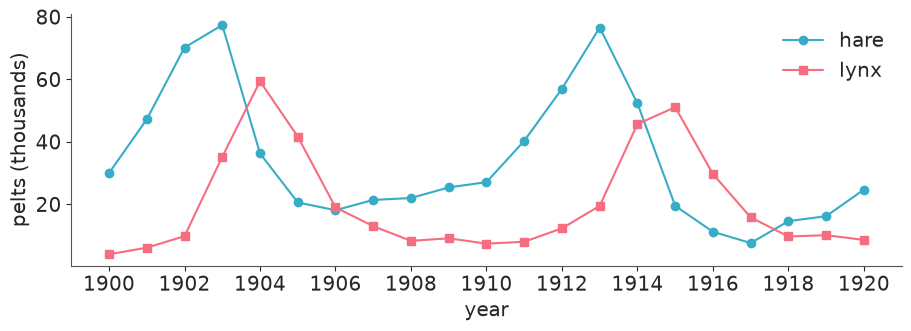

In [2]:
data.describe("lynx_hare")
pelts = data.load("lynx_hare")
obs = pelts[["Hare", "Lynx"]].to_numpy()  # column 0 = prey, column 1 = predator
log_obs = np.log(obs)
YEARS = pelts.Year.to_numpy()
N_YEARS = len(pelts) - 1  # 20 intervals; t = 0 is the year 1900
SPECIES = ["hare", "lynx"]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(YEARS, obs[:, 0], "o-", label="hare")
ax.plot(YEARS, obs[:, 1], "s-", label="lynx")
ax.set(xlabel="year", ylabel="pelts (thousands)", xticks=YEARS[::2])
ax.legend();

With $H$ hares and $L$ lynx, the three models differ only in what they claim to know about
the right-hand side.

| | hares $\dot H$ | lynx $\dot L$ | assumes |
|---|---|---|---|
| **mechanistic** (E09) | $\alpha H - \beta H L$ | $-\gamma L + \delta H L$ | everything: linear birth and death, mass-action predation. 4 rates |
| **hybrid, from scratch** | $\alpha H - H\,g_1(H, L)$ | $-\gamma L + L\,g_2(H, L)$ | linear birth and death; predation hurts hares and feeds lynx ($g \ge 0$); nothing about its form |
| **hybrid, physics in the prior** | $\alpha H - \beta H L\,e^{c_1(H, L)}$ | $-\gamma L + \delta H L\,e^{c_2(H, L)}$ | as above, plus: mass action is *roughly* right. The network is a multiplicative correction, and its prior says how far from 1 it may stray |
| **black box** | $H\,f_1(H, L)$ | $L\,f_2(H, L)$ | populations stay positive. Nothing else |

$g$, $c$ and $f$ are small neural networks. Why is it reasonable to call the linear terms
"known"? They are statements about one species alone - hares without predators multiply,
lynx without prey starve - that can be measured without ever watching the two interact.
The interaction is the part an ecologist argues about: mass action, or a predator that
gets full (Holling's type II response), or prey that hide when predators are many.

As in E09 everything is integrated on the log scale, $x = \log H$, $y = \log L$, where the
three right-hand sides read $\dot x = \alpha - \beta e^{y}$ (mechanistic),
$\dot x = \alpha - g_1$ (from scratch), $\dot x = \alpha - \beta e^{y + c_1}$ (physics in
the prior) and $\dot x = f_1$ (black box), and the solver output is the location of a
LogNormal likelihood.

**One deliberate difference from E09: a single noise scale $\sigma$ for both species.**
E09 gave each species its own and both came out near 0.25. Give a *flexible* model two
noise scales and it spends its freedom fitting the smoother lynx series almost exactly
($\sigma_{\text{lynx}} \approx 0.08$ at the optimum when I tried it) while explaining the
hares as noise - a funnel that also wrecked the sampling. The measurement process is the
same for both species (trappers, one company's ledgers), so one $\sigma$ is the better
model, and all three models share it to keep the comparison fair.

## 2 · The network and the solver, in JAX

**The network is a pure function of one flat weight vector.** Equinox would work
(`wrap_jax` accepts pytrees, as E09 showed), but it would buy nothing at this size and cost
clarity. A flat vector means PyMC owns the weights as *one* random variable with a
`weight` dimension, there is exactly one `pt.specify_shape` at the boundary, the prior scale
is one number, and the symmetries of section 6 can be written as index permutations. The
layers are unpacked by slicing, which costs nothing under `jit`.

Both networks have two inputs (the standardised log populations), one hidden layer of
`N_HIDDEN = 3` tanh units and two outputs. Three units is small even by the standards of
this literature; section 4 explains why more would not fit in this notebook.

- `mlp`: the ordinary network, $W_2 \tanh(W_1 s + b_1) + b_2$, 17 weights. Used by the
  black box and the from-scratch hybrid.
- `correction`: $W_2\,[\tanh(W_1 s + b_1) - \tanh(b_1)]$, 15 weights. No output bias, and
  zero at $s = 0$ by construction, so that $\beta$ and $\delta$ keep a meaning: they are the
  interaction rates *at the centre of the data*. It is the network analogue of centring a
  regressor.

In [3]:
N_HIDDEN = 3
CENTER = jnp.asarray(log_obs.mean(axis=0))
SCALE = jnp.asarray(log_obs.std(axis=0))


def hidden_layer(w, log_z):
    W1, b1 = w[: 2 * N_HIDDEN].reshape(N_HIDDEN, 2), w[2 * N_HIDDEN : 3 * N_HIDDEN]
    return jnp.tanh(W1 @ ((log_z - CENTER) / SCALE) + b1), jnp.tanh(b1)


def mlp(w, log_z):
    h, _ = hidden_layer(w, log_z)
    return w[3 * N_HIDDEN : 5 * N_HIDDEN].reshape(2, N_HIDDEN) @ h + w[5 * N_HIDDEN :]


def correction(w, log_z):
    h, h_centre = hidden_layer(w, log_z)
    return w[3 * N_HIDDEN : 5 * N_HIDDEN].reshape(2, N_HIDDEN) @ (h - h_centre)


# every right-hand side has the same signature, so one solver serves all models
def rhs_mechanistic(log_z, rates, w):
    alpha, beta, gamma, delta = rates
    return jnp.stack([alpha - beta * jnp.exp(log_z[1]), -gamma + delta * jnp.exp(log_z[0])])


def rhs_scratch(log_z, rates, w):
    g = jax.nn.softplus(mlp(w, log_z))  # per-capita predation loss and gain, both >= 0
    return jnp.stack([rates[0] - g[0], -rates[1] + g[1]])


def rhs_hybrid(log_z, rates, w):
    alpha, beta, gamma, delta = rates
    c = correction(w, log_z)
    return jnp.stack([alpha - beta * jnp.exp(log_z[1] + c[0]), -gamma + delta * jnp.exp(log_z[0] + c[1])])


def rhs_blackbox(log_z, rates, w):
    return mlp(w, log_z)


RHS = {"mechanistic": rhs_mechanistic, "scratch": rhs_scratch, "hybrid": rhs_hybrid, "blackbox": rhs_blackbox}
N_WEIGHTS = {"mechanistic": 1, "scratch": 5 * N_HIDDEN + 2, "hybrid": 5 * N_HIDDEN, "blackbox": 5 * N_HIDDEN + 2}
units = range(N_HIDDEN)
WEIGHT_NAMES = (
    [f"W1[{j},{s}]" for j in units for s in SPECIES] + [f"b1[{j}]" for j in units]
    + [f"W2[{s},{j}]" for s in SPECIES for j in units]
)

The solver is E09's fixed-step RK4 in a `lax.scan`, generalised to take the right-hand side
as an argument. One change: **2 steps per year instead of 20.** Every gradient evaluation
costs a forward and a backward pass through the whole scan, NUTS will want millions of
them, and a ten-year cycle does not need a step of 18 days. The check:

In [4]:
def make_solver(rhs, n_years=N_YEARS, substeps=2):
    dt = 1.0 / substeps

    def solve(rates, w, log_z0):
        def substep(z, _):
            k1 = rhs(z, rates, w)
            k2 = rhs(z + 0.5 * dt * k1, rates, w)
            k3 = rhs(z + 0.5 * dt * k2, rates, w)
            k4 = rhs(z + dt * k3, rates, w)
            return z + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4), None

        def to_next_year(z, _):
            z, _ = jax.lax.scan(substep, z, None, length=substeps)
            return z, z

        _, path = jax.lax.scan(to_next_year, log_z0, None, length=n_years)
        return jnp.concatenate([log_z0[None], path])  # (n_years + 1, 2): log hare, log lynx

    return solve


theta_e09 = jnp.array([0.55, 0.028, 0.79, 0.024])  # E09's posterior means
reference = make_solver(rhs_mechanistic, substeps=200)(theta_e09, jnp.zeros(1), jnp.asarray(log_obs[0]))
for substeps in [1, 2, 5, 20]:
    path = make_solver(rhs_mechanistic, substeps=substeps)(theta_e09, jnp.zeros(1), jnp.asarray(log_obs[0]))
    print(f"{substeps:>3} RK4 steps per year: max error on the log scale = {float(jnp.abs(path - reference).max()):.1e}")

  1 RK4 steps per year: max error on the log scale = 6.0e-02
  2 RK4 steps per year: max error on the log scale = 3.3e-03
  5 RK4 steps per year: max error on the log scale = 9.7e-05
 20 RK4 steps per year: max error on the log scale = 4.3e-07


Two steps per year are wrong by a few thousandths on the log scale - about seventy times
smaller than the observation noise ($\sigma \approx 0.25$). One step per year would not be
good enough. Section 9 repeats the check on the fitted networks, where it matters more.

### The PyMC model

One builder for all three models. `n_train` is there for the forecast in section 9: the
model then integrates and sees only the first `n_train` years. Priors on the rates, the
initial state and the noise are E09's. The weights get `Normal(0, w_scale)`; the choice of
`w_scale` is the subject of section 5.

In [5]:
RATES = ["alpha", "beta", "gamma", "delta"]


def build_model(kind, n_train=N_YEARS + 1, w_scale=1.0):
    solver_pt = pytensor.wrap_jax(make_solver(RHS[kind], n_years=n_train - 1))
    coords = {"year": YEARS[:n_train], "species": SPECIES}
    if kind != "mechanistic":
        coords["weight"] = WEIGHT_NAMES if kind == "hybrid" else [*WEIGHT_NAMES, "b2[hare]", "b2[lynx]"]
    with pm.Model(coords=coords) as model:
        if kind == "blackbox":
            rates = pt.zeros(1)  # a placeholder: the black box has no physical parameters
        else:
            rates = pt.stack([
                pm.LogNormal("alpha", np.log(1.0), 0.5), pm.LogNormal("beta", np.log(0.05), 1.0),
                pm.LogNormal("gamma", np.log(1.0), 0.5), pm.LogNormal("delta", np.log(0.05), 1.0),
            ])
        if kind == "mechanistic":
            w = pt.zeros(1)
        else:
            w = pm.Normal("w", 0.0, w_scale, dims="weight")
            w = pt.specify_shape(w, (N_WEIGHTS[kind],))  # dims= loses the static shape (E09, section 4)
        z0 = pm.LogNormal("z0", np.log(10.0), 1.0, dims="species")
        sigma = pm.LogNormal("sigma", -1.0, 1.0)

        log_mu = solver_pt(rates, w, pt.log(pt.specify_shape(z0, (2,))))
        pm.Deterministic("log_mu", log_mu, dims=("year", "species"))
        pm.LogNormal("pelts", log_mu, sigma, observed=obs[:n_train], dims=("year", "species"))
    return model


W_SCALE = {"mechanistic": 1.0, "hybrid": 0.3, "blackbox": 1.0}  # justified in section 5
models = {kind: build_model(kind, w_scale=W_SCALE[kind]) for kind in W_SCALE}
models["hybrid"]

### Check the gradient, and price it

`wrap_jax` gets its gradient from `jax.vjp`, so there is little to get wrong - but "little"
is not "nothing" (a `stop_gradient` left in, a non-differentiable branch), and the check is
cheap. `verify_grad` compares the pullback with finite differences along random
projections, here through 40 RK4 steps and the network. The weak part of such a check is
the finite differences, not the gradient: with the rates on their natural scale
($\beta \approx 0.03$, and a trajectory that is very sensitive to it) my first version
failed with a relative error of $2 \times 10^{-4}$ against a tolerance of $10^{-4}$, at a
point where forward- and reverse-mode differentiation agree to sixteen digits. So the
check is done where the sampler works, on the log-rates, and backed by that second,
finite-difference-free comparison.

In [6]:
hybrid_solver_pt = pytensor.wrap_jax(make_solver(rhs_hybrid))
test_point = [np.log([0.55, 0.028, 0.79, 0.024]), rng.normal(0, 0.3, N_WEIGHTS["hybrid"]), log_obs[0].copy()]
verify_grad(lambda log_rates, w, log_z0: hybrid_solver_pt(pt.exp(log_rates), w, log_z0), test_point, rng=rng)
print("verify_grad: passed for the log-rates, the 15 weights and the initial state")

jax_point = (jnp.exp(test_point[0]), jnp.asarray(test_point[1]), jnp.asarray(test_point[2]))
forward = jax.jacfwd(make_solver(rhs_hybrid), argnums=(0, 1, 2))(*jax_point)
reverse = jax.jacrev(make_solver(rhs_hybrid), argnums=(0, 1, 2))(*jax_point)
print("forward- vs reverse-mode Jacobian, largest relative difference: %.0e"
      % max(float(jnp.abs(f - r).max() / jnp.abs(f).max()) for f, r in zip(forward, reverse)))

verify_grad: passed for the log-rates, the 15 weights and the initial state


forward- vs reverse-mode Jacobian, largest relative difference: 2e-15


What NUTS pays per step is one evaluation of the log-density and its gradient. The JAX
backend (the whole model as one XLA program, E09's Route 3) is what the fits below use.

In [7]:
def time_logp_grad(model, mode="JAX", n=300):
    logp = model.logp()
    fn = pytensor.function(model.value_vars, [logp, *pt.grad(logp, model.value_vars)], mode=mode)
    point = model.initial_point()
    args = [point[v.name] for v in model.value_vars]
    fn(*args)
    start = time.perf_counter()
    for _ in range(n):
        fn(*args)
    return (time.perf_counter() - start) / n * 1e3


cost_table = pd.DataFrame({
    kind: {"free parameters": sum(v.size for v in model.initial_point().values()),
           "logp + gradient, JAX mode (ms)": round(time_logp_grad(model), 3)}
    for kind, model in models.items()
}).T
cost_table["free parameters"] = cost_table["free parameters"].astype(int)
cost_table

,free parameters,"logp + gradient, JAX mode (ms)"
mechanistic,7,0.023
hybrid,22,0.205
blackbox,20,0.101


A fraction of a millisecond each (timings vary from run to run; read ratios). The network
is not free: forty RK4 steps with four network evaluations each, forwards and backwards,
make a hybrid gradient several times dearer than a mechanistic one. But at these prices the
per-gradient cost is not what decides whether a fit is affordable. What decides it is how
many gradients the sampler needs per draw. For the mechanistic model that is about five.
Hold that thought.

### The baseline: E09's model, again

Same recipe as E09 - start from the physically motivated point, no jitter, low-rank mass
matrix - wrapped in a helper that every fit in this notebook goes through. The helper
records the diagnostics that make sense for *every* model here: those of the predicted
trajectory `log_mu`, which is a function-space quantity. `maxdepth=8` caps a NUTS
trajectory at 255 leapfrog steps (the default cap is 1023); the reason will become clear.

In [8]:
fit_log = {}


def run_nuts(label, model, initvals, tune=500, draws=500):
    start = time.perf_counter()
    with model:
        idata = pm.sample(
            tune=tune, draws=draws, random_seed=RANDOM_SEED, initvals=initvals, progressbar=False,
            nuts_sampler="nutpie", backend="jax", nuts={"adaptation": "low_rank", "maxdepth": 8},
            compile_kwargs={"gradient_backend": "jax", "jitter_rvs": set()},
        )
    stats = idata.sample_stats
    summary = az.summary(idata, var_names=["log_mu", "sigma"])
    fit_log[label] = {
        "wall time (s)": round(time.perf_counter() - start),
        "draws": f"4 x ({tune} + {draws})",
        "divergences": int(stats["diverging"].sum()),
        "leapfrog steps per draw": round(float(stats["n_steps"].mean())),
        "share of draws at the depth cap": round(float((stats["n_steps"] >= 255).mean()), 2),
        "trajectory: max r_hat": round(float(summary["r_hat"].max()), 3),
        "trajectory: min bulk ESS": int(summary["ess_bulk"].min()),
    }
    return idata


omega0 = 2 * np.pi / 10  # E09, section 8: a ten-year cycle around the observed mean populations
physics_start = {"alpha": omega0, "gamma": omega0, "beta": omega0 / obs[:, 1].mean(),
                 "delta": omega0 / obs[:, 0].mean(), "z0": obs[0]}

fits = {"mechanistic": run_nuts("mechanistic", models["mechanistic"], physics_start, tune=1000, draws=1000)}
pd.DataFrame(fit_log).T

NUTS[nutpie]: [alpha, beta, gamma, delta, z0, sigma]


,wall time (s),draws,divergences,leapfrog steps per draw,share of draws at the depth cap,trajectory: max r_hat,trajectory: min bulk ESS
mechanistic,3,4 x (1000 + 1000),0,5,0.0,1.003,3310


In [9]:
az.summary(fits["mechanistic"], var_names=[*RATES, "z0", "sigma"], ci_kind="hdi", ci_prob=0.94, round_to=3)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.552,0.059,0.442,0.660,4212.304,3026.714,1.000,0.001,0.001
beta,0.028,0.004,0.021,0.036,4192.936,2800.668,1.000,0.000,0.000
gamma,0.790,0.081,0.644,0.943,4318.778,2961.093,1.000,0.001,0.002
delta,0.024,0.003,0.018,0.030,4541.763,3248.220,1.000,0.000,0.000
z0[hare],34.190,2.883,29.045,39.988,5067.644,3270.996,1.000,0.041,0.048
z0[lynx],5.965,0.490,5.013,6.852,4982.820,3308.200,1.001,0.007,0.007
sigma,0.242,0.029,0.193,0.297,3310.963,3049.227,1.001,0.001,0.000


A few seconds, no divergences, a handful of leapfrog steps per draw, and the same rates as
E09 ($\alpha \approx 0.55$, $\beta \approx 0.028$, $\gamma \approx 0.79$,
$\delta \approx 0.024$) with one shared $\sigma \approx 0.25$. Neither the coarser solver
nor the shared noise scale changed the answer. This is the yardstick for everything below.

## 3 · First attempt: learn the interaction from scratch

The textbook universal differential equation: $\dot x = \alpha - g_1(x, y)$,
$\dot y = -\gamma + g_2(x, y)$ with $g = \text{softplus}(\text{mlp})$ and `Normal(0, 1)`
weights. Before sampling anything, *optimise* it - this is what most of the literature
does, and we need a starting point anyway, because a randomly initialised neural ODE is
nowhere near an oscillator.

The log-posterior is written directly in JAX (it is five lines) so that the whole
optimisation can be vectorised: `jax.vmap` over 32 random initialisations of an Adam loop
inside one `lax.scan`. Thirty-two complete trainings of a neural ODE take a few seconds.

In [10]:
def make_neg_log_posterior(kind, n_train=N_YEARS + 1, w_scale=1.0):
    solve = make_solver(RHS[kind], n_years=n_train - 1)
    y = jnp.asarray(log_obs[:n_train])

    def neg_log_posterior(u):  # u: a dict of unconstrained parameters
        path = solve(jnp.exp(u["log_rates"]), u["w"], u["log_z0"])
        logp = (
            jstats.norm.logpdf(y, path, jnp.exp(u["log_sigma"])).sum()
            + jstats.norm.logpdf(u["w"], 0.0, w_scale).sum()
            + jstats.norm.logpdf(u["log_z0"], np.log(10.0), 1.0).sum()
            + jstats.norm.logpdf(u["log_sigma"], -1.0, 1.0)
        )
        if kind == "scratch":  # alpha and gamma; the black box ignores its `log_rates`
            logp = logp + jstats.norm.logpdf(u["log_rates"], 0.0, 0.5).sum()
        return -logp

    return neg_log_posterior


def multistart(kind, n_train=N_YEARS + 1, n_starts=32, steps=3000, learning_rate=0.02, seed=0):
    neg_log_posterior = make_neg_log_posterior(kind, n_train)
    start_rng = np.random.default_rng(seed)
    u0 = {
        "log_rates": jnp.asarray(start_rng.normal(0, 0.3, (n_starts, 2))),
        "w": jnp.asarray(start_rng.normal(0, 1.0, (n_starts, N_WEIGHTS[kind]))),  # draws from the prior
        "log_z0": jnp.asarray(np.tile(log_obs[0], (n_starts, 1))),
        "log_sigma": jnp.full((n_starts,), -0.5),
    }
    optimiser = optax.adam(learning_rate)
    value_and_grad = jax.vmap(jax.value_and_grad(neg_log_posterior))

    @jax.jit
    def train(u):
        def step(carry, _):
            u, state = carry
            _, grads = value_and_grad(u)
            updates, state = jax.vmap(optimiser.update)(grads, state)
            return (optax.apply_updates(u, updates), state), None

        (u, _), _ = jax.lax.scan(step, (u, jax.vmap(optimiser.init)(u)), None, length=steps)
        return u, jax.vmap(neg_log_posterior)(u)

    u, final = train(u0)
    return {name: np.asarray(value) for name, value in u.items()}, np.asarray(final)


start = time.perf_counter()
scratch_u, scratch_loss = multistart("scratch")
print(f"32 trainings of 3000 Adam steps: {time.perf_counter() - start:.1f} s")
print("final negative log-posterior, sorted:")
print(np.round(np.sort(scratch_loss), 1))

32 trainings of 3000 Adam steps: 2.4 s
final negative log-posterior, sorted:
[13.7 13.8 13.8 14.1 14.2 14.6 14.8 15.  15.1 16.6 17.6 17.9 19.4 19.5
 21.6 30.1 56.  56.4 56.6 58.4 59.7 59.7 59.7 59.7 59.7 59.9 60.  60.7
 61.6 64.3 68.7 84.8]


12 of 32 runs end within 5 nats of the best; 16 are more than 25 nats worse


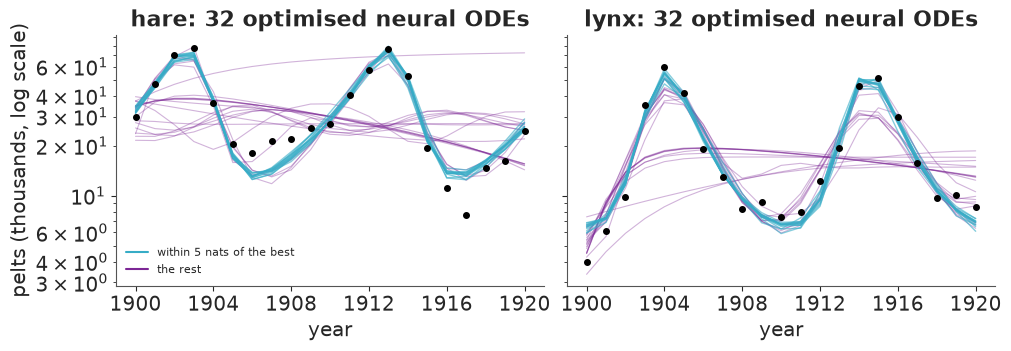

In [11]:
good = np.flatnonzero(scratch_loss < scratch_loss.min() + 5)
print(f"{len(good)} of 32 runs end within 5 nats of the best; "
      f"{int((scratch_loss > scratch_loss.min() + 25).sum())} are more than 25 nats worse")

scratch_solver = jax.jit(jax.vmap(make_solver(rhs_scratch)))
scratch_paths = np.exp(np.asarray(scratch_solver(
    jnp.exp(scratch_u["log_rates"]), jnp.asarray(scratch_u["w"]), jnp.asarray(scratch_u["log_z0"]))))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, i, species in zip(axes, [0, 1], SPECIES):
    ax.plot(YEARS, scratch_paths[np.setdiff1d(np.arange(32), good)][:, :, i].T, color="C3", alpha=0.35, lw=0.8)
    ax.plot(YEARS, scratch_paths[good][:, :, i].T, color="C0", alpha=0.6, lw=1)
    ax.plot(YEARS, obs[:, i], "ko", ms=4)
    ax.set(yscale="log", title=f"{species}: 32 optimised neural ODEs", xlabel="year", xticks=YEARS[::4])
axes[0].set_ylabel("pelts (thousands, log scale)")
axes[0].plot([], [], color="C0", label="within 5 nats of the best")
axes[0].plot([], [], color="C3", label="the rest")
axes[0].legend(fontsize=8);

Two lessons already. **The objective is multimodal in the way E09 warned about, only more
so**: half of the runs end in a poor local optimum - trajectories that damp out to a level
line through the data, or that catch the first cycle and lose the second - 25 nats or more
worse than the best. A single training run would have had an even chance of reporting
failure. And **the good runs agree**: about a dozen end within a few nats of each other,
their trajectories are nearly indistinguishable, and they reproduce both cycles.

Did they learn the same *mechanism*, and is it mass action? The identifiable quantity is the
net per-capita growth rate, $\alpha - g_1$ for hares and $-\gamma + g_2$ for lynx ($\alpha$
and the level of $g_1$ can be traded against each other). Mass action makes two sharp
predictions: hare growth falls linearly in $L$ and *does not depend on $H$*; lynx growth
rises linearly in $H$ and does not depend on $L$. Below, one abundance varies over its
observed range while the other species is held at its median; each good run is one line,
against the 90% posterior band of the mechanistic model.

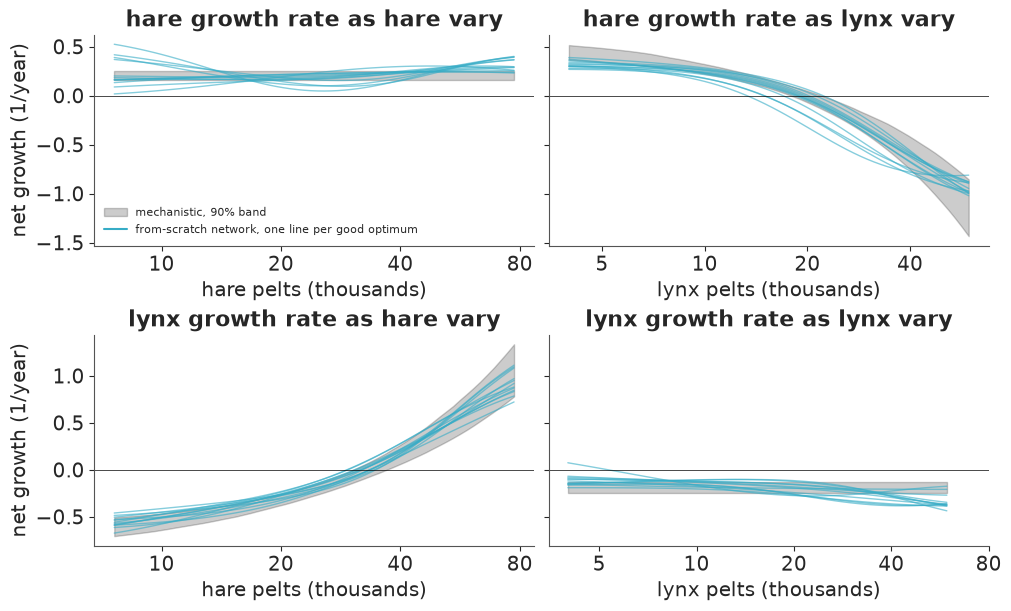

In [12]:
mech_post = az.extract(fits["mechanistic"], var_names=RATES, num_samples=500, random_seed=RANDOM_SEED)
mech_rates = np.stack([mech_post[r].values for r in RATES], axis=1)  # (500, 4)

median_state = np.median(log_obs, axis=0)
slices = {}
for i, species in enumerate(SPECIES):  # vary one log-population over its observed range, hold the other at its median
    states = np.tile(median_state, (60, 1))
    states[:, i] = np.linspace(log_obs[:, i].min(), log_obs[:, i].max(), 60)
    slices[species] = jnp.asarray(states)

field_scratch = jax.jit(jax.vmap(jax.vmap(rhs_scratch, in_axes=(0, None, None)), in_axes=(None, 0, 0)))
field_mech = jax.jit(jax.vmap(jax.vmap(rhs_mechanistic, in_axes=(0, None, None)), in_axes=(None, 0, None)))

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey="row")
for col, varied in enumerate(SPECIES):
    grid = slices[varied]
    ensemble = np.asarray(field_scratch(grid, jnp.exp(scratch_u["log_rates"][good]), jnp.asarray(scratch_u["w"][good])))
    mech = np.asarray(field_mech(grid, jnp.asarray(mech_rates), jnp.zeros(1)))
    x = np.exp(np.asarray(grid)[:, col])
    for row, species in enumerate(SPECIES):
        ax = axes[row, col]
        lo, hi = np.quantile(mech[:, :, row], [0.05, 0.95], axis=0)
        ax.fill_between(x, lo, hi, color="k", alpha=0.2, label="mechanistic, 90% band")
        ax.plot(x, ensemble[:, :, row].T, color="C0", alpha=0.6, lw=1)
        ax.axhline(0, color="k", lw=0.5)
        ax.set(xscale="log", xlabel=f"{varied} pelts (thousands)",
               title=f"{species} growth rate as {varied} vary", xticks=[5, 10, 20, 40, 80][col == 0:], xticklabels=[5, 10, 20, 40, 80][col == 0:])
        ax.minorticks_off()
    axes[0, col].plot([], [], color="C0", label="from-scratch network, one line per good optimum")
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_ylabel("net growth (1/year)")
axes[1, 0].set_ylabel("net growth (1/year)");

Read the top-right and bottom-left panels first: hare growth falls as lynx increase and
lynx growth rises with hares, with the right sign, nearly the right curve (a straight line
in the abundance is an exponential on this log axis), and the zero crossing - the
equilibrium - where the mechanistic model puts it. Nothing told the network any of that
beyond the signs. The other two panels are the test mass action could fail: the growth of a
species should be *flat* in its own abundance. The optimised networks stay close to the
flat band. For hares they fan out at the low-abundance end, some up and some down; for lynx
most of them tilt gently downwards at high lynx numbers (a hint of crowding among
predators, or nothing). So a network that knows nothing about predation recovers the shape
of the mass-action law from 21 years of pelts, and the optima disagree with each other
mostly where that law makes its most specific claim.

"The optima disagree" is a poor man's uncertainty statement. A spread of point estimates
from different initialisations (a "deep ensemble") is not a posterior: it says nothing
about the width of each mode, and the runs were selected by me. What we want is the
posterior.

## 4 · Inference, honestly: why I could not sample that model here

The natural next cell would wrap `rhs_scratch` in the model builder, start NUTS at the best
optimum and report a posterior. I did that, many times. **None of those fits is in this
notebook, because none was both trustworthy and affordable.** What I measured while
preparing it (nutpie, low-rank mass matrix, 4 chains started at the best optimum, on the
busy 8-core laptop that built this page):

| network | settings | wall time | what happened |
|---|---|---|---|
| 2-8-2, two $\sigma$ | defaults, depth cap 10 | > 10 min | killed |
| 2-5-2, two $\sigma$ | 1000 + 500 draws, depth cap 8 | 260 s | 220 leapfrog steps per draw, weights $\hat R$ 1.6, trajectory $\hat R$ 1.04, ESS 74 |
| 2-4-2, one $\sigma$ | 700 + 500, cap 8 | 120 s | trajectory $\hat R$ 1.04, ESS 124 |
| 2-3-2, one $\sigma$ | 700 + 500, cap 8 | 120 s | trajectory $\hat R$ 1.05 - 1.19 depending on the seed |
| 2-2-2, one $\sigma$ | 700 + 500, cap 8 | 75 - 130 s | trajectory $\hat R$ 1.02, 1.11, 1.12, 1.48 over four runs |
| 2-4-2, one $\sigma$ | 1000 + 1000, cap 6 and cap 5 | cheaper | worse: trajectory $\hat R$ 1.11 and 1.46 - shorter trajectories do not help |

("Two $\sigma$" is E09's noise model, one scale per species; section 1 explains why I
dropped it.) Shrinking the network to two hidden units did not rescue it, nor did fixing
$\alpha$ and $\gamma$, an exponential instead of a softplus output, centring the network,
NumPyro with vectorised chains, or a tighter weight prior (which made the *optimisation*
fail more often). The step size always adapted to about 0.03 - 0.06 and most draws ran into
the depth cap. The reason is visible in the curvature at the optimum:

In [13]:
best = int(np.argmin(scratch_loss))
neg_log_posterior = make_neg_log_posterior("scratch")
flat0, unravel = ravel_pytree({name: jnp.asarray(value[best]) for name, value in scratch_u.items()})
objective = jax.jit(jax.value_and_grad(lambda flat: neg_log_posterior(unravel(flat))))
polished = scipy.optimize.minimize(lambda v: tuple(np.asarray(o) for o in objective(jnp.asarray(v))),
                                   np.asarray(flat0), jac=True, method="L-BFGS-B",
                                   options={"maxiter": 20_000, "maxfun": 50_000, "ftol": 1e-15, "gtol": 1e-8})
hessian = np.asarray(jax.hessian(lambda flat: neg_log_posterior(unravel(flat)))(jnp.asarray(polished.x)))
eigenvalues = np.linalg.eigvalsh(hessian)
print(f"Adam end point {scratch_loss[best]:.2f} -> L-BFGS {polished.fun:.2f}  (gradient norm {np.linalg.norm(polished.jac):.1e})")
print("Hessian eigenvalues of the negative log-posterior at the optimum (22 parameters):")
print(np.array2string(eigenvalues, precision=1, suppress_small=True, max_line_width=100))
print(f"implied posterior sd: {1 / np.sqrt(eigenvalues.max()):.4f} in the stiffest direction, "
      f"{1 / np.sqrt(eigenvalues[eigenvalues > 0].min()):.2f} in the softest")

Adam end point 13.75 -> L-BFGS 12.51  (gradient norm 2.6e-04)
Hessian eigenvalues of the negative log-posterior at the optimum (22 parameters):
[       0.2        1.7        2.4        2.5        3.3        3.5        4.4        5.8        7.4
        9.7       11.4       22.7       45.7       84.2      117.3      168.5      308.       711.4
     4032.2    12567.     51305.3 22444517.9]
implied posterior sd: 0.0002 in the stiffest direction, 2.00 in the softest


(Adam had not quite converged, which is why the optimum is polished with L-BFGS first; a
Hessian away from a stationary point means little.) The stiffest direction is pinned down
to a posterior standard deviation of about 0.0002 and the softest are as wide as the prior,
of order one: **a ratio of several thousand** in a local Gaussian approximation. The stiff
direction has a simple origin. On the log scale a constant error $\epsilon$ in a growth
rate grows into an error $\epsilon t$ in the trajectory, so twenty years of data constrain
the *average* growth rate along the orbit to a few parts in a thousand, and the period
almost as tightly. In the mechanistic model that constraint is a fixed linear combination
of four log-rates, and the low-rank mass matrix absorbs it - five leapfrog steps per draw.
In the network the same constraint is a *curved* sheet in a 17-dimensional weight space,
because which combination of weights sets the average growth rate depends on where in
weight space you are. No linear preconditioner straightens a curved sheet. NUTS has to
walk along prior-wide directions with steps sized for the thin one: hundreds of gradient
evaluations per draw, and even then the chains diffuse too slowly to agree.

Longer trajectories do fix it. The one network fit with a prior this loose that I let run
to the default depth cap (the model of the next section at `w_scale = 1`) mixed well -
trajectory $\hat R$ 1.01 - at about 800 leapfrog steps per draw: ten minutes for one fit.
That is the honest price of a loosely constrained Bayesian neural ODE with NUTS, on a
problem with 42 data points. It is why the published examples use long runs, stochastic-gradient samplers or
variational approximations - and why the black-box fit below, which has the same geometry
and no physics to lean on, will come with a warning label.

## 5 · The fix: put the physics in the prior

The from-scratch network spends most of its capacity re-deriving what we already
believed. The alternative is to keep mass action and let the network multiply it:

$$
\dot x = \alpha - \beta\,e^{y}\,e^{c_1(x, y)}, \qquad \dot y = -\gamma + \delta\,e^{x}\,e^{c_2(x, y)}
$$

With all weights zero, $c \equiv 0$ and this *is* Lotka-Volterra. A Holling type II
response would show up as $c_1, c_2$ falling with $H$; prey refuge as $c$ falling with
$L$. The network is now a *residual* on trusted physics (the usual role of the network in
a universal differential equation), and the prior scale of the weights acquires a meaning
a scientist can argue about: **how far from mass action am I prepared to go before seeing
data?**

### Priors over weights are priors over functions

Nobody has prior beliefs about `W1[2,lynx]`. The way to choose `w_scale` is to look at what
it implies in *function* space: the correction factor $e^{c}$ over the region the data
visit, and the trajectories. Priors this simple can be drawn with NumPy and pushed through
the same JAX solver with `vmap`; `w_scale = 0` is the mechanistic prior of E09. The figure
shows, for three scales, 60 prior hare trajectories (top) and the prior distribution of the
correction factor $e^{c_1}$ at one corner of the region the data visit - many hares *and*
many lynx (bottom).

In [14]:
n_prior = 1000
prior_rng = np.random.default_rng(RANDOM_SEED)
prior_rates = jnp.asarray(np.exp(prior_rng.normal(np.log([1.0, 0.05, 1.0, 0.05]), [0.5, 1.0, 0.5, 1.0], (n_prior, 4))))
prior_z0 = jnp.asarray(prior_rng.normal(np.log(10.0), 1.0, (n_prior, 2)))
unit_weights = prior_rng.normal(size=(n_prior, N_WEIGHTS["hybrid"]))

grid_axes = [np.linspace(log_obs[:, i].min(), log_obs[:, i].max(), 15) for i in range(2)]
state_grid = jnp.asarray(np.stack(np.meshgrid(*grid_axes, indexing="ij"), axis=-1).reshape(-1, 2))  # (225, 2)
correction_on_grid = jax.jit(jax.vmap(jax.vmap(correction, in_axes=(None, 0)), in_axes=(0, None)))
hybrid_solver = jax.jit(jax.vmap(make_solver(rhs_hybrid)))

hybrid_solver_fine = jax.jit(jax.vmap(make_solver(rhs_hybrid, substeps=100)))

prior_scales = [0.0, 0.1, 0.3, 1.0]
prior_paths, prior_factor, rows = {}, {}, {}
for scale in prior_scales:
    w = jnp.asarray(scale * unit_weights)
    paths = np.asarray(hybrid_solver(prior_rates, w, prior_z0))  # log scale, (n_prior, 21, 2)
    factor = np.exp(np.asarray(correction_on_grid(w, state_grid)))  # (n_prior, 225, 2)
    finite = np.isfinite(paths).all(axis=(1, 2))
    prior_paths[scale], prior_factor[scale] = paths, factor
    fold = np.exp(np.abs(np.log(factor)))  # 1.3 means "30% above or below mass action"
    still_bad = 0
    if (~finite).any():  # numerical or real? solve the failed draws again with 100 steps per year
        redo = np.asarray(hybrid_solver_fine(prior_rates[~finite], w[~finite], prior_z0[~finite]))
        still_bad = int((~np.isfinite(redo).all(axis=(1, 2))).sum())
    rows[f"w_scale = {scale}"] = {
        "draws with inf/NaN (2 steps/year)": int((~finite).sum()),
        "... of those, still inf/NaN at 100 steps/year": still_bad,
        "correction factor: typical fold-change": round(float(np.median(fold)), 2),
        "... 95th percentile": round(float(np.quantile(fold, 0.95)), 2),
        "trajectories leaving 0.1 - 1000 thousand pelts": round(float(
            ((paths[finite].max(axis=(1, 2)) > np.log(1000)) | (paths[finite].min(axis=(1, 2)) < np.log(0.1))).mean()), 2),
    }
pd.DataFrame(rows).T

,draws with inf/NaN (2 steps/year),"... of those, still inf/NaN at 100 steps/year",correction factor: typical fold-change,... 95th percentile,trajectories leaving 0.1 - 1000 thousand pelts
w_scale = 0.0,0.0,0.0,1.00,1.00,0.29
w_scale = 0.1,0.0,0.0,1.01,1.06,0.31
w_scale = 0.3,0.0,0.0,1.10,1.52,0.45
w_scale = 1.0,10.0,0.0,1.79,13.16,0.62


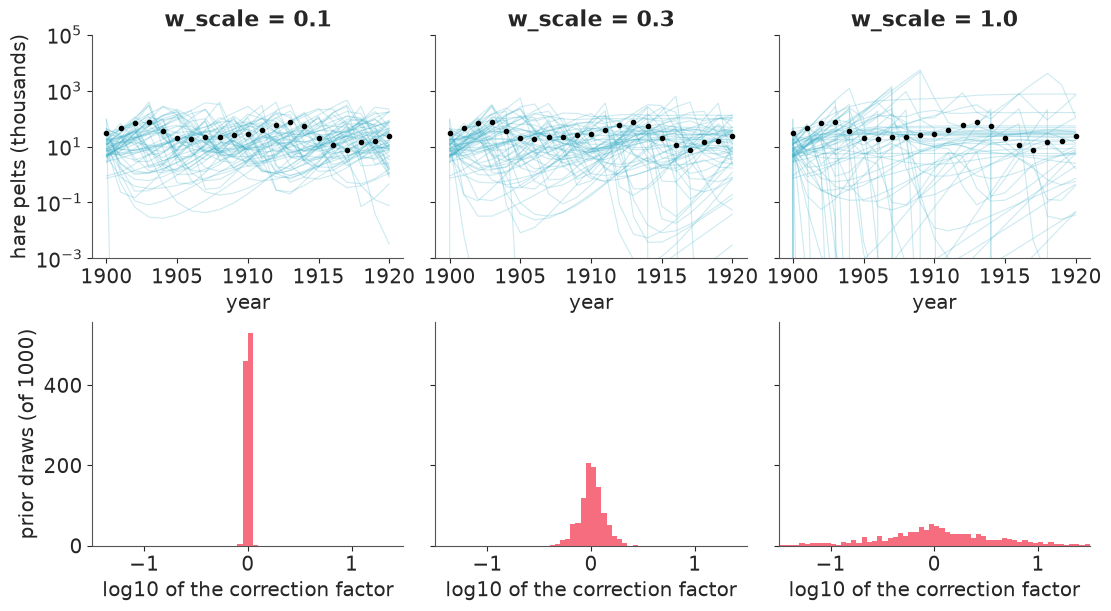

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharey="row")
corner = int(np.argmax(np.asarray(state_grid).sum(axis=1)))  # many hares AND many lynx: a corner of the data region
for col, scale in enumerate(prior_scales[1:]):
    axes[0, col].plot(YEARS, np.exp(prior_paths[scale][:60, :, 0]).T, color="C0", alpha=0.25, lw=0.8)
    axes[0, col].plot(YEARS, obs[:, 0], "ko", ms=3)
    axes[0, col].set(yscale="log", ylim=(1e-3, 1e5), title=f"w_scale = {scale}", xlabel="year", xticks=YEARS[::5])
    axes[1, col].hist(np.log10(prior_factor[scale][:, corner, 0]), bins=np.linspace(-1.5, 1.5, 61), color="C1")
    axes[1, col].set(xlabel="log10 of the correction factor", xlim=(-1.5, 1.5))
axes[0, 0].set_ylabel("hare pelts (thousands)")
axes[1, 0].set_ylabel("prior draws (of 1000)");

**Blow-ups first.** A neural ODE with random weights is the classic source of NaNs, and
the handling here has three layers. *Design*: the state is a log-population, so no solver
error can produce a negative population, and the hidden units are `tanh`, so the
correction factor is bounded for any input however far a trajectory strays; the exact
solution of such a system cannot reach infinity in finite time. (E09's section 10 shows
what the natural scale does instead: negative populations, then NaN in the likelihood.)
*Count, never silently drop*: the table reports non-finite draws, and statistics are
computed on the finite ones. At `w_scale` up to 0.3 there are none. At 1.0, ten draws in a
thousand fail - and every one of them is finite when solved again with 100 steps per
year. Those failures are the *solver*, not the dynamics: a wild network makes the dynamics
fast somewhere, and RK4 with two steps a year is only stable while nothing happens on a
time scale much shorter than a year. *In the sampler*: nutpie treats a non-finite
log-density as a rejected, divergent proposal and carries on, so an unstable corner of
parameter space costs a divergence, not a crash - and section 9 checks the step size on the
posterior draws that matter.

**Then the functions.** The milder kind of blowing up - trajectories that leave any
plausible range, above a million pelts or below a hundred - happens for 29% of draws from
the mechanistic prior (E09 showed those and accepted them), for about the same share at
`w_scale = 0.1`, 45% at 0.3 and 62% at 1.0. The mechanism tells the same story. At 0.1 the
network rarely moves the interaction by more than 6% anywhere in the region the data
visit: a Lotka-Volterra model with extra steps. At 1.0 the typical draw changes predation
by a factor of 1.8 and one draw in twenty by a factor of 13 or more, *within the range of
populations actually observed* - the prior has all but forgotten mass action, and we are
back in the geometry of section 4. **`w_scale = 0.3`** says: mass action is right to within
about 10% in a typical place, and to within a factor of 1.5 nineteen times in twenty. That
is a statement I can defend - loose enough for a type II response to show itself, tight
enough to be a *correction* - and it is what `models["hybrid"]` was built with. It is also a
knob you can turn; "Try it yourself" asks you to.

## 6 · Fitting the hybrid, and how to check a network posterior

The residual network has a natural starting point that needs no optimisation at all: E09's
physical start for the rates and weights near zero. (Exactly zero would be a poor choice -
with $W_2 = 0$ the gradient with respect to the first layer vanishes - so the weights start
at a small random value, the same for every chain.)

In [16]:
hybrid_start = {**physics_start, "w": np.random.default_rng(0).normal(0, 0.05, N_WEIGHTS["hybrid"])}
fits["hybrid"] = run_nuts("hybrid", models["hybrid"], hybrid_start)
pd.DataFrame(fit_log).T

NUTS[nutpie]: [alpha, beta, gamma, delta, w, z0, sigma]


,wall time (s),draws,divergences,leapfrog steps per draw,share of draws at the depth cap,trajectory: max r_hat,trajectory: min bulk ESS
mechanistic,3,4 x (1000 + 1000),0,5,0.0,1.003,3310
hybrid,47,4 x (500 + 500),13,98,0.0,1.011,1671


Under a minute rather than ten. A hundred leapfrog steps per draw is still twenty times
the mechanistic model's appetite - the curved sheet of section 4 has not gone away, the
prior has only made it small enough to cross - and a dozen divergences (under 1% of the
draws) are a reminder of that. No draw reached the depth cap. On the trajectory, $\hat R$
and ESS are fine.

### $\hat R$ on weights is the wrong question

A one-hidden-layer tanh network computes *exactly* the same function if you permute its
hidden units, or flip the sign of all weights into and out of one unit (tanh is odd). With
three units that is $3! \times 2^3 = 48$ weight vectors per function, and the Gaussian prior is
blind to the difference, so the posterior has 48 identical copies of everything. Four
chains that each explore a *different* copy have sampled the same posterior over functions,
and their weight-space $\hat R$ says they disagree completely. We can manufacture that
situation without running anything: map three of our four chains to other copies, which
are equally valid posterior draws, and recompute.

In [17]:
def symmetric_copy(w, permutation, signs):
    """Relabel and sign-flip the hidden units: a different weight vector, exactly the same function."""
    H, lead = N_HIDDEN, w.shape[:-1]
    W1, b1 = w[..., : 2 * H].reshape(*lead, H, 2), w[..., 2 * H : 3 * H]
    W2, b2 = w[..., 3 * H : 5 * H].reshape(*lead, 2, H), w[..., 5 * H :]  # b2 is empty for `correction`
    W1 = (W1 * signs[:, None])[..., permutation, :]
    b1 = (b1 * signs)[..., permutation]
    W2 = (W2 * signs)[..., permutation]
    return np.concatenate([W1.reshape(*lead, -1), b1, W2.reshape(*lead, -1), b2], axis=-1)


w_draws = fits["hybrid"].posterior["w"].values  # (chain, draw, weight)
copies = [([0, 1, 2], [1, 1, 1]), ([1, 2, 0], [1, -1, 1]), ([2, 0, 1], [-1, 1, -1]), ([0, 2, 1], [-1, -1, 1])]
w_relabelled = np.stack([symmetric_copy(w_draws[c], perm, np.array(sign)) for c, (perm, sign) in enumerate(copies)])

probe = jnp.asarray(log_obs)
same_function = np.abs(np.asarray(correction_on_grid(jnp.asarray(w_relabelled[1]), probe))
                       - np.asarray(correction_on_grid(jnp.asarray(w_draws[1]), probe))).max()
print(f"largest change in the correction c(H, L) after relabelling chain 1: {same_function:.1e}")


def rhat_ess(array, name="f"):
    """Worst r_hat and smallest bulk ESS over the trailing dimensions of a (chain, draw, ...) array."""
    dims = ["chain", "draw", *[f"{name}_dim{i}" for i in range(array.ndim - 2)]]
    dataset = xr.Dataset({name: (dims, array)})
    return float(az.rhat(dataset)[name].max()), float(az.ess(dataset)[name].min())


print("r_hat of the weights, chains as sampled        : max %.3f" % rhat_ess(w_draws)[0])
print("r_hat of the weights, three chains relabelled  : max %.3f" % rhat_ess(w_relabelled)[0])

largest change in the correction c(H, L) after relabelling chain 1: 1.1e-16
r_hat of the weights, chains as sampled        : max 1.008
r_hat of the weights, three chains relabelled  : max 1.008


The relabelled chains define the same functions to machine precision - and here the weight
$\hat R$ does not move either. That is not what I expected when I wrote the cell, and it is
instructive. At `w_scale = 0.3` the 48 copies are not separate modes: they overlap around
zero and merge into one symmetric blob, and every chain already wanders through all of
them, so relabelling a chain changes nothing statistically. The black box of section 8,
whose weights must be large to produce an oscillation at all, shows the other case. In
*both* cases the weight marginals are useless, as a look at them makes plain:

In [18]:
w_summary = az.summary(fits["hybrid"], var_names=["w"], round_to=2)[["mean", "sd", "ess_bulk", "r_hat"]]
w_summary["sd / prior sd"] = (w_summary["sd"] / W_SCALE["hybrid"]).round(2)
w_summary.T

,"w[W1[0,hare]]","w[W1[0,lynx]]","w[W1[1,hare]]","w[W1[1,lynx]]","w[W1[2,hare]]","w[W1[2,lynx]]",w[b1[0]],w[b1[1]],w[b1[2]],"w[W2[hare,0]]","w[W2[hare,1]]","w[W2[hare,2]]","w[W2[lynx,0]]","w[W2[lynx,1]]","w[W2[lynx,2]]"
mean,-0.01,-0.00,0.01,0.00,0.01,0.01,-0.00,-0.00,0.01,-0.01,0.01,-0.00,-0.00,0.01,-0.00
sd,0.26,0.27,0.27,0.27,0.27,0.26,0.30,0.32,0.31,0.27,0.27,0.27,0.26,0.26,0.26
ess_bulk,1131.99,1022.56,1064.60,654.12,737.72,915.80,3157.36,2768.26,2846.47,994.65,900.53,879.62,647.97,822.52,700.25
r_hat,1.00,1.00,1.00,1.01,1.00,1.01,1.00,1.00,1.01,1.01,1.00,1.01,1.00,1.00,1.01
sd / prior sd,0.87,0.90,0.90,0.90,0.90,0.87,1.00,1.07,1.03,0.90,0.90,0.90,0.87,0.87,0.87


Every weight has posterior mean zero to two decimals and a standard deviation of 87% to
107% of its prior's 0.3. Read weight by weight, the data taught this network next to
*nothing* - which is false, as section 7 shows. What the data constrain are products and
combinations of weights, in a sign- and permutation-symmetric way that leaves almost no
trace in any marginal. Weights are not parameters in the sense of E01-E10: they have no
meaning, no identifiability, and no business in a summary table. A good $\hat R$ on them
proves as little as a bad one.

### Convergence in function space

What must converge is what you will report: the predicted trajectory at each year, the
learned right-hand side $(\dot x, \dot y)$ on a grid of states covering the data, and the
log-likelihood (a scalar summary of fit that is invariant under every symmetry). The
black box goes through the same checks in section 8.

In [19]:
vector_field = {kind: jax.jit(jax.vmap(jax.vmap(RHS[kind], in_axes=(0, None, None)), in_axes=(None, 0, 0)))
                for kind in ["mechanistic", "hybrid", "blackbox"]}
coarse_grid = jnp.asarray(np.stack(np.meshgrid(*[g[::2] for g in grid_axes], indexing="ij"), axis=-1).reshape(-1, 2))  # 8 x 8


def flat_draws(kind, idata):
    """Posterior draws as flat JAX arrays (rates, w, log_z0), chains concatenated."""
    post = idata.posterior
    n = post.sizes["chain"] * post.sizes["draw"]
    rates = np.stack([post[r].values.reshape(n) for r in RATES], axis=1) if kind != "blackbox" else np.zeros((n, 1))
    w = post["w"].values.reshape(n, -1) if kind != "mechanistic" else np.zeros((n, 1))
    log_z0 = np.log(post["z0"].values.reshape(n, 2))
    return jnp.asarray(rates), jnp.asarray(w), jnp.asarray(log_z0)


def function_space_report(kind, idata, model):
    with model:
        pm.compute_log_likelihood(idata, progressbar=False)
    n_chain, n_draw = idata.posterior.sizes["chain"], idata.posterior.sizes["draw"]
    rates, w, _ = flat_draws(kind, idata)
    field = np.asarray(vector_field[kind](coarse_grid, rates, w)).reshape(n_chain, n_draw, -1, 2)
    quantities = {
        "predicted trajectory, 21 years x 2": idata.posterior["log_mu"].values,
        "right-hand side on an 8 x 8 grid of states": field,
        "log-likelihood (total)": idata.log_likelihood["pelts"].sum(("year", "species")).values,
        "sigma": idata.posterior["sigma"].values,
    }
    if kind != "mechanistic":
        quantities = {"the weights": idata.posterior["w"].values, **quantities}
    return pd.DataFrame({name: dict(zip(["max r_hat", "min bulk ESS"], rhat_ess(values)))
                         for name, values in quantities.items()}).T.round({"max r_hat": 3, "min bulk ESS": 0})


function_space_report("hybrid", fits["hybrid"], models["hybrid"])

,max r_hat,min bulk ESS
the weights,1.008,648.0
"predicted trajectory, 21 years x 2",1.011,1671.0
right-hand side on an 8 x 8 grid of states,1.005,1084.0
log-likelihood (total),1.003,740.0
sigma,1.004,2293.0


Every function-space quantity has $\hat R$ of about 1.01 or better and at least 700
effective draws out of 2000: good enough for the means and 90% bands reported below. The usual caveat from E09 applies with more force: all chains started at
the same point, so this shows that they agree with each other, not that there is no
second, functionally different mode they all missed. Section 9 meets one.

### Cheap approximations, judged in function space

If NUTS is this expensive, do the usual shortcuts work? Mean-field ADVI and Pathfinder,
both from the same starting point. Two practical notes, both learned the hard way. ADVI's
default initial standard deviation of 1 on the unconstrained scale throws its first
samples into regions where the ODE gradient is astronomically large, and the optimisation
returns NaN within a few iterations; `start_sigma` of 0.05 and gradient clipping fix that
(full-rank ADVI has no `start_sigma` and produced NaN regardless, so it is not shown).
And `pmx.fit_pathfinder` forks worker processes by default, which deadlocks against the
initialised JAX runtime exactly as PyMC's own NUTS did in E09: `parallel=False`.

In [20]:
start = time.perf_counter()
with models["hybrid"]:
    small_sigma = {name: np.full(np.shape(value), 0.05) for name, value in models["hybrid"].initial_point().items()}
    advi = pm.fit(
        n=15_000, method=pm.ADVI(start=hybrid_start, start_sigma=small_sigma, random_seed=RANDOM_SEED),
        obj_optimizer=pm.adam(learning_rate=0.003), total_grad_norm_constraint=50.0, progressbar=False,
    )
    idata_advi = advi.sample(1000, random_seed=RANDOM_SEED)
time_advi = time.perf_counter() - start

start = time.perf_counter()
with models["hybrid"]:
    idata_pathfinder = pmx.fit_pathfinder(num_paths=4, num_draws=1000, jitter=0.1, initvals=hybrid_start,
                                          parallel=False, progressbar=False, random_seed=RANDOM_SEED)
time_pathfinder = time.perf_counter() - start


def stacked(idata, name):
    values = idata.posterior[name].values
    return values.reshape(-1, *values.shape[2:])


def correction_draws(idata):
    w = stacked(idata, "w")
    return np.asarray(correction_on_grid(jnp.asarray(w), coarse_grid))


nuts_mu, nuts_c = stacked(fits["hybrid"], "log_mu"), correction_draws(fits["hybrid"])
approximations = {"NUTS": (fits["hybrid"], fit_log["hybrid"]["wall time (s)"]),
                  "mean-field ADVI": (idata_advi, time_advi), "Pathfinder": (idata_pathfinder, time_pathfinder)}
pd.DataFrame({
    label: {
        "wall time (s)": round(seconds),
        "trajectory: largest shift of the mean, in NUTS sd": round(float(
            (np.abs(stacked(idata, "log_mu").mean(0) - nuts_mu.mean(0)) / nuts_mu.std(0)).max()), 2),
        "trajectory: sd relative to NUTS (mean over years)": round(float((stacked(idata, "log_mu").std(0) / nuts_mu.std(0)).mean()), 2),
        "correction c on the grid: sd relative to NUTS": round(float((correction_draws(idata).std(0) / nuts_c.std(0)).mean()), 2),
        "weights: mean posterior sd": round(float(stacked(idata, "w").std(0).mean()), 3),
        "sigma: posterior mean": round(float(idata.posterior["sigma"].mean()), 3),
    }
    for label, (idata, seconds) in approximations.items()
}).T

Finished [100%]: Average Loss = 162.17


,wall time (s),"trajectory: largest shift of the mean, in NUTS sd",trajectory: sd relative to NUTS (mean over years),correction c on the grid: sd relative to NUTS,weights: mean posterior sd,sigma: posterior mean
NUTS,47.0,0.00,1.00,1.00,0.275,0.245
mean-field ADVI,7.0,1.43,1.71,0.24,0.149,0.251
Pathfinder,7.0,1.11,1.21,0.22,0.073,0.265


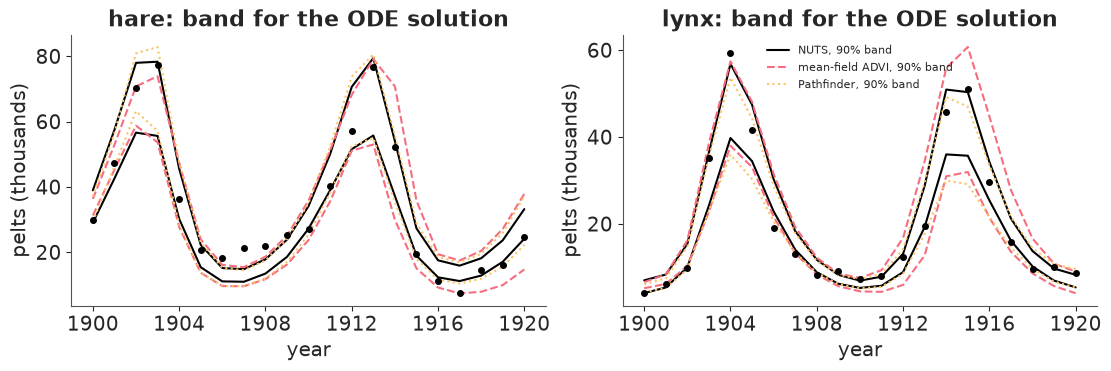

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, i, species in zip(axes, [0, 1], SPECIES):
    for (label, (idata, _)), color, style in zip(approximations.items(), ["k", "C1", "C2"], ["-", "--", ":"]):
        lo, hi = np.quantile(np.exp(stacked(idata, "log_mu")[:, :, i]), [0.05, 0.95], axis=0)
        ax.plot(YEARS, lo, color=color, ls=style, label=f"{label}, 90% band")
        ax.plot(YEARS, hi, color=color, ls=style)
    ax.plot(YEARS, obs[:, i], "ko", ms=4)
    ax.set(title=f"{species}: band for the ODE solution", xlabel="year", xticks=YEARS[::4], ylabel="pelts (thousands)")
axes[1].legend(fontsize=8, loc="upper center");

Both shortcuts run in seconds and put the trajectory roughly where NUTS does (the mean is
off by up to one to one and a half posterior standard deviations in some years). Both get
the *uncertainty* wrong, and in two opposite directions at once.

- **The trajectory band is too wide**: 1.7 times for mean-field ADVI, 1.2 times for
  Pathfinder. The folklore says mean-field ADVI underestimates uncertainty; that is a
  statement about parameter marginals. Here the data pin down a few *combinations* of
  parameters extremely tightly (section 4), a factorised Gaussian cannot represent a
  combination, and so each parameter wobbles independently and the period and the average
  growth rate wobble with them - visibly, in the second cycle. Pathfinder's low-rank
  covariance captures part of it.
- **The mechanism band is far too narrow**: the standard deviation of the learned
  correction is a quarter of the NUTS value for both. The correction is a *product* of
  first- and second-layer weights whose posterior is the symmetric blob of the last
  section; a single Gaussian centred near zero with shrunken widths (ADVI's weight
  standard deviations come out at about half of NUTS's, Pathfinder's at about a quarter)
  turns that into a network that is confidently almost switched off.

So an approximation can look conservative on the quantity you plotted and be badly
overconfident on the one you did not. Either shortcut is a reasonable way to find a
starting point or to screen model variants. Neither is a substitute for the posterior when
the width of a band *is* the result, which in this notebook it is.

## 7 · The scientific payoff: what did the network learn about predation?

The honest framing first. Because the prior is centred on mass action, this model cannot
"rediscover" mass action - section 3 is the closest we get to that, with optimisation only.
The question a Bayesian hybrid answers is the one a scientist would actually pose: **do
the data call for a departure from mass action, where in state space, and how sure are
we?** Three views.

**Where did the data teach the network anything?** The ratio of posterior to prior
standard deviation of the correction $c(H, L)$, over the region of state space the data
visit. A ratio of 1 means "still the prior".

posterior median of the correction factors inside the box: 0.96 to 1.04; anywhere on the map: 0.93 to 1.08
posterior sd / prior sd of the correction c, median over grid points
   inside the box the data span : 0.58   (range 0.33 - 0.79)
   outside it                   : 0.64   (range 0.36 - 0.81)
90% band of the factor exp(c1): at the centre of the data [1, 1] by construction; widest inside the box [0.71, 1.44]; widest outside [0.55, 1.82]


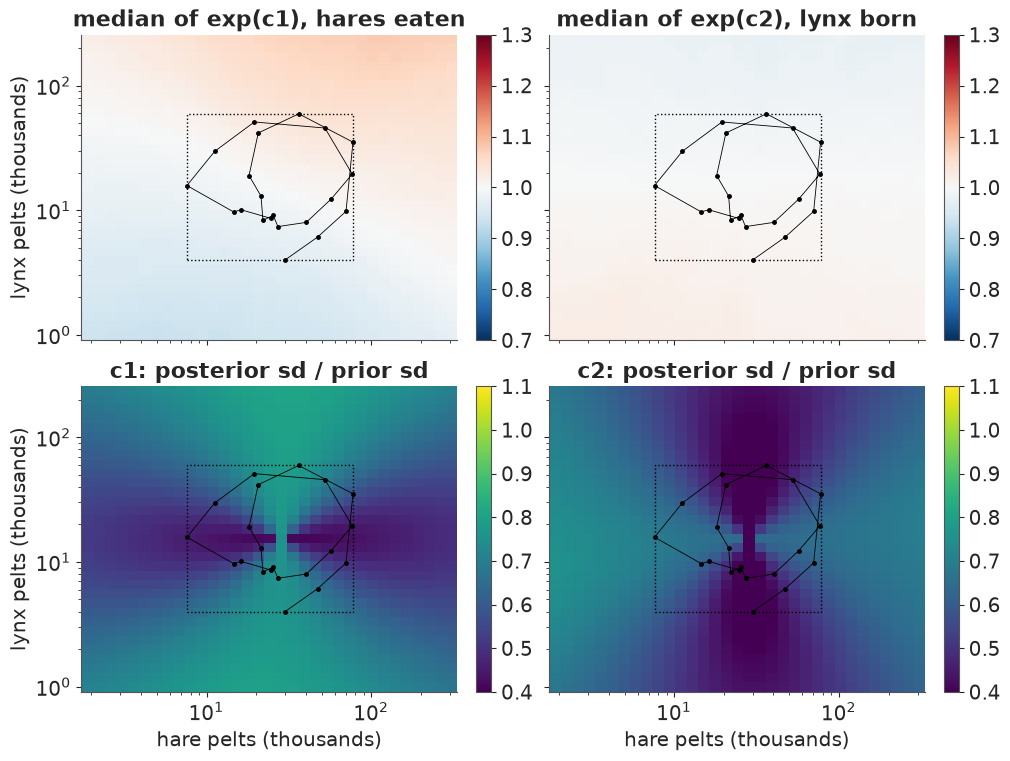

In [22]:
# a grid that reaches a factor of four beyond the observed populations on every side
wide_axes = [np.linspace(log_obs[:, i].min() - np.log(4), log_obs[:, i].max() + np.log(4), 33) for i in range(2)]
wide_grid = np.stack(np.meshgrid(*wide_axes, indexing="ij"), axis=-1).reshape(-1, 2)
inside = np.all((wide_grid >= log_obs.min(axis=0)) & (wide_grid <= log_obs.max(axis=0)), axis=1)

posterior_c = np.asarray(correction_on_grid(jnp.asarray(stacked(fits["hybrid"], "w")), jnp.asarray(wide_grid)))  # (2000, 1089, 2)
prior_c = np.asarray(correction_on_grid(jnp.asarray(0.3 * unit_weights), jnp.asarray(wide_grid)))
shape = (len(wide_axes[0]), len(wide_axes[1]))
box = np.exp(np.r_[log_obs.min(axis=0), log_obs.max(axis=0)])  # hare min, lynx min, hare max, lynx max

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5), sharex=True, sharey=True)
for col, (k, label) in enumerate([(0, "exp(c1), hares eaten"), (1, "exp(c2), lynx born")]):
    median_factor = np.exp(np.median(posterior_c[:, :, k], axis=0)).reshape(shape)
    sd_ratio = (posterior_c[:, :, k].std(axis=0) / prior_c[:, :, k].std(axis=0)).reshape(shape)
    for row, (field, cmap, limits, title) in enumerate([
        (median_factor, "RdBu_r", (0.7, 1.3), f"median of {label}"),
        (sd_ratio, "viridis", (0.4, 1.1), f"c{k + 1}: posterior sd / prior sd"),
    ]):
        ax = axes[row, col]
        mesh = ax.pcolormesh(np.exp(wide_axes[0]), np.exp(wide_axes[1]), field.T, cmap=cmap, vmin=limits[0], vmax=limits[1], shading="nearest")
        fig.colorbar(mesh, ax=ax)
        ax.plot(obs[:, 0], obs[:, 1], "k.-", lw=0.6, ms=5)
        ax.add_patch(plt.Rectangle(box[:2], *(box[2:] - box[:2]), fill=False, ls=":", lw=1))
        ax.set(xscale="log", yscale="log", title=title)
for ax in axes[1]:
    ax.set_xlabel("hare pelts (thousands)")
for ax in axes[:, 0]:
    ax.set_ylabel("lynx pelts (thousands)")

ratio = posterior_c.std(axis=0) / prior_c.std(axis=0)
medians = np.exp(np.median(posterior_c, axis=0))
print(f"posterior median of the correction factors inside the box: {medians[inside].min():.2f} to {medians[inside].max():.2f}; "
      f"anywhere on the map: {medians.min():.2f} to {medians.max():.2f}")
print("posterior sd / prior sd of the correction c, median over grid points")
print(f"   inside the box the data span : {np.median(ratio[inside]):.2f}   (range {ratio[inside].min():.2f} - {ratio[inside].max():.2f})")
print(f"   outside it                   : {np.median(ratio[~inside]):.2f}   (range {ratio[~inside].min():.2f} - {ratio[~inside].max():.2f})")
print(f"90% band of the factor exp(c1): at the centre of the data [1, 1] by construction; "
      f"widest inside the box [{np.exp(np.quantile(posterior_c[:, inside, 0], 0.05, axis=0)).min():.2f}, "
      f"{np.exp(np.quantile(posterior_c[:, inside, 0], 0.95, axis=0)).max():.2f}]; "
      f"widest outside [{np.exp(np.quantile(posterior_c[:, ~inside, 0], 0.05, axis=0)).min():.2f}, "
      f"{np.exp(np.quantile(posterior_c[:, ~inside, 0], 0.95, axis=0)).max():.2f}]")

**Does the interaction look like mass action where it is constrained?** The per-capita
predation rate $\beta L\,e^{c_1}$ as lynx vary, and the per-capita lynx gain
$\delta H\,e^{c_2}$ as hares vary (the other species at its median), against the straight
lines $\beta L$ and $\delta H$ of the mechanistic fit. The ticks along the bottom mark the
observed abundances.

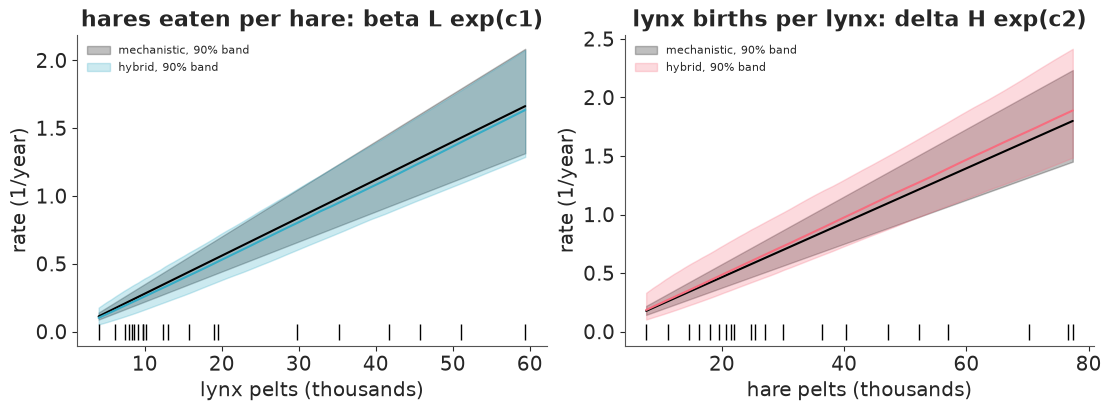

In [23]:
hyb_rates, hyb_w, _ = flat_draws("hybrid", fits["hybrid"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, varied, k, rate, title in [
    (axes[0], "lynx", 0, 1, "hares eaten per hare: beta L exp(c1)"),
    (axes[1], "hare", 1, 3, "lynx births per lynx: delta H exp(c2)"),
]:
    grid = slices[varied]
    other = np.exp(np.asarray(grid)[:, 1 - k])  # the abundance of the species that drives this term
    c = np.asarray(correction_on_grid(hyb_w, grid))[:, :, k]
    for values, color, label in [
        (mech_rates[:, [rate]] * other, "k", "mechanistic"),
        (np.asarray(hyb_rates)[:, [rate]] * other * np.exp(c), f"C{k}", "hybrid"),
    ]:
        lo, mid, hi = np.quantile(values, [0.05, 0.5, 0.95], axis=0)
        ax.fill_between(other, lo, hi, color=color, alpha=0.25, label=f"{label}, 90% band")
        ax.plot(other, mid, color=color)
    ax.plot(obs[:, 1 - k], np.zeros(len(obs)), "k|", ms=12)
    ax.set(xlabel=f"{varied} pelts (thousands)", ylabel="rate (1/year)", title=title)
    ax.legend(fontsize=8, loc="upper left");

**A symbolic summary with uncertainty.** If the interaction were a power law,
$U_1 \propto H^{a} L^{b}$, then $a = 1 + \partial c_1 / \partial x$ and
$b = 1 + \partial c_1 / \partial y$; mass action is $a = b = 1$, a saturating type II
response has $a < 1$. `jax.jacobian` gives those elasticities for free. We average them over
the observed states, once per posterior draw, and do the same for draws from the prior.

In [24]:
elasticity = jax.jit(jax.vmap(lambda w: jax.vmap(jax.jacobian(correction, argnums=1), in_axes=(None, 0))(w, probe).mean(axis=0)))
posterior_el = 1 + np.asarray(elasticity(hyb_w))  # (draws, output k, input): d log U_k / d log (H, L)
prior_el = 1 + np.asarray(elasticity(jnp.asarray(0.3 * unit_weights)))

rows = {}
for k, term in enumerate(["U1, hares eaten", "U2, lynx born"]):
    for j, name in enumerate(["H", "L"]):
        lo, hi = np.quantile(posterior_el[:, k, j], [0.05, 0.95])
        plo, phi = np.quantile(prior_el[:, k, j], [0.05, 0.95])
        rows[f"{term}: exponent of {name}"] = {
            "mass action": 1.0, "posterior mean": posterior_el[:, k, j].mean().round(2),
            "90% interval": f"[{lo:.2f}, {hi:.2f}]", "prior 90% interval": f"[{plo:.2f}, {phi:.2f}]",
            "P(exponent < 1)": (posterior_el[:, k, j] < 1).mean().round(2),
        }
pd.DataFrame(rows).T

,mass action,posterior mean,90% interval,prior 90% interval,P(exponent < 1)
"U1, hares eaten: exponent of H",1.0,1.01,"[0.88, 1.15]","[0.69, 1.31]",0.44
"U1, hares eaten: exponent of L",1.0,1.04,"[0.85, 1.25]","[0.73, 1.25]",0.39
"U2, lynx born: exponent of H",1.0,1.0,"[0.79, 1.23]","[0.71, 1.33]",0.5
"U2, lynx born: exponent of L",1.0,0.99,"[0.90, 1.09]","[0.75, 1.25]",0.57


Three views, one answer: **no detectable departure from mass action - and a usefully sharp
statement of how large a departure the data would still allow.**

- The posterior median of both correction factors stays within a few percent of 1 over the
  whole region the data visit, and the rate curves of the hybrid lie on top of the
  mechanistic straight lines with a slightly wider band.
- The data *did* teach the network something: inside the box, the posterior standard
  deviation of the correction is about 0.6 of the prior's, down to a third in places. The
  map shows what was learned. For $c_1$ the constraint is tightest along a horizontal band:
  along the *hare* axis at typical lynx numbers. For $c_2$ it is a vertical band: along the
  *lynx* axis. Those are exactly the specific claims of mass action - hares eaten *per
  hare* does not depend on hares, lynx born *per lynx* does not depend on lynx - and the
  same place where the optimised networks of section 3 disagreed with each other. (The
  thin seam through the centre of each map is a ratio of two numbers that are both zero
  there by construction.)
- The exponent table says it in numbers. The exponent of $H$ in $U_1$ is 1.0 with a 90%
  interval of about $\pm 0.14$, and the exponent of $L$ in $U_2$ is 1.0 $\pm 0.10$, against
  prior intervals of $\pm 0.3$ and $\pm 0.25$: twenty-one years of pelts confirm those two
  mass-action exponents to within 10 - 15%. The two *cross* exponents ($L$ in $U_1$, $H$ in
  $U_2$) come back with intervals barely narrower than the prior's. Whether predation is exactly
  linear in the number of predators, or bends a little, these data cannot say - presumably
  because over a single orbit such a bend can be absorbed by the four rates. Every
  $P(\text{exponent} < 1)$ is between 0.4 and 0.6: no sign of a saturating response, and
  no evidence against one of modest size.
- **Away from the data the uncertainty does not explode**, and that is a warning, not a
  comfort. Outside the box the posterior-to-prior ratio barely rises (0.64 against 0.58)
  and the widest 90% band for the factor goes from [0.71, 1.44] inside to [0.55, 1.82]
  outside. The network has not learned anything about a world with 300 thousand hares.
  `tanh` units saturate, so a small network extrapolates whatever it believes at the edge
  of the data as a constant, and the prior caps the rest. A Gaussian process would revert
  to its prior away from the data; this model does not. Know what your architecture does
  in extrapolation before you read an uncertainty map.

## 8 · The black box, with its warning label

$\dot x = f_1(x, y)$, $\dot y = f_2(x, y)$ with `Normal(0, 1)` weights: no physics to centre
a prior on, so no residual trick, so the geometry of section 4 in full. It needs the
multi-start optimisation to find a starting point, and it gets the same sampler budget as
the hybrid with fewer retained draws.

In [25]:
def blackbox_start(n_train=N_YEARS + 1):
    u, loss = multistart("blackbox", n_train)
    i = int(np.argmin(loss))
    print(f"multi-start ({n_train} years): {int((loss < loss.min() + 5).sum())} of 32 runs within 5 nats of the best")
    return {"w": u["w"][i], "z0": np.exp(u["log_z0"][i]), "sigma": float(np.exp(u["log_sigma"][i]))}


fits["blackbox"] = run_nuts("blackbox", models["blackbox"], blackbox_start(), tune=500, draws=300)
pd.DataFrame(fit_log).T

NUTS[nutpie]: [w, z0, sigma]


multi-start (21 years): 12 of 32 runs within 5 nats of the best


,wall time (s),draws,divergences,leapfrog steps per draw,share of draws at the depth cap,trajectory: max r_hat,trajectory: min bulk ESS
mechanistic,3,4 x (1000 + 1000),0,5,0.0,1.003,3310
hybrid,47,4 x (500 + 500),13,98,0.0,1.011,1671
blackbox,50,4 x (500 + 300),15,207,0.71,1.121,26


In [26]:
pd.concat({kind: function_space_report(kind, fits[kind], models[kind]) for kind in ["mechanistic", "blackbox"]})

max r_hat  \
mechanistic predicted trajectory, 21 years x 2              1.003   
            right-hand side on an 8 x 8 grid of states      1.001   
            log-likelihood (total)                          1.000   
            sigma                                           1.001   
blackbox    the weights                                     1.839   
            predicted trajectory, 21 years x 2              1.121   
            right-hand side on an 8 x 8 grid of states      1.343   
            log-likelihood (total)                          1.120   
            sigma                                           1.039   

                                                        min bulk ESS  
mechanistic predicted trajectory, 21 years x 2                4180.0  
            right-hand side on an 8 x 8 grid of states        4021.0  
            log-likelihood (total)                            1715.0  
            sigma                                             3311.0  
blackbox    the weights                                          6.0  
            predicted trajectory, 21 years x 2                  27.0  
            right-hand side on an 8 x 8 grid of states          10.0  
            log-likelihood (total)                              25.0  
            sigma                                              176.0

In [27]:
mlp_on_states = jax.jit(jax.vmap(jax.vmap(mlp, in_axes=(None, 0)), in_axes=(0, None)))
bb_w = fits["blackbox"].posterior["w"].values
bb_relabelled = np.stack([symmetric_copy(bb_w[c], perm, np.array(sign)) for c, (perm, sign) in enumerate(copies)])
change = np.abs(np.asarray(mlp_on_states(jnp.asarray(bb_relabelled[2]), probe)) - np.asarray(mlp_on_states(jnp.asarray(bb_w[2]), probe))).max()
print(f"largest change in the black-box right-hand side after relabelling chain 2: {change:.1e}")
print("r_hat of the weights, chains as sampled       : max %.2f, median %.2f" % (rhat_ess(bb_w)[0], np.median(az.rhat(xr.Dataset({"w": (["chain", "draw", "k"], bb_w)}))["w"])))
print("r_hat of the weights, three chains relabelled : max %.2f, median %.2f" % (rhat_ess(bb_relabelled)[0], np.median(az.rhat(xr.Dataset({"w": (["chain", "draw", "k"], bb_relabelled)}))["w"])))

largest change in the black-box right-hand side after relabelling chain 2: 4.4e-16
r_hat of the weights, chains as sampled       : max 1.84, median 1.45
r_hat of the weights, three chains relabelled : max 2.04, median 1.54


The same sampler budget, a very different outcome: about 200 leapfrog steps per draw, 70%
of the draws stopped by the depth cap, and function-space diagnostics that would fail any
model in E01-E10 - trajectory $\hat R$ 1.12 with an ESS in the twenties, $\hat R$ 1.3 for
the right-hand side on the grid. (The mechanistic model, for reference, is at 1.00 on
everything.) **This fit has not converged**, and I am not going to spend ten minutes of
your time making it converge. Everything below that uses it carries that label: its
posterior means are indicative, and its band widths and tail probabilities are not to be
trusted. That is itself a finding about the black-box end of the spectrum: with no physics
to centre a prior on, even the *computation* becomes unreliable at a data size where the
mechanistic model samples in seconds.

The relabelling experiment now does what section 6 promised. The three relabelled chains
compute the same functions to sixteen digits, and the weight $\hat R$ moves from 1.84 to
2.04 (median 1.45 to 1.54): the diagnostic changed, and nothing about the posterior over
functions did. For a network with separated modes, $\hat R$ on weights mostly measures
which of the 48 copies each chain happens to sit in. The function-space numbers are the
ones that say this fit is in trouble.

## 9 · Three models, compared honestly

### In sample

In [28]:
def posterior_paths(kind, idata):
    """Solve the ODE over all 21 years for every posterior draw - also beyond the years a model was fitted to."""
    rates, w, log_z0 = flat_draws(kind, idata)
    return np.asarray(jax.jit(jax.vmap(make_solver(RHS[kind])))(rates, w, log_z0))


fine_solvers = {kind: jax.jit(jax.vmap(make_solver(RHS[kind], substeps=50))) for kind in fits}
in_sample = {}
for kind, idata in fits.items():
    paths = posterior_paths(kind, idata)
    thin = [a[::10] for a in flat_draws(kind, idata)]
    in_sample[kind] = {
        "sigma (posterior mean)": round(float(idata.posterior["sigma"].mean()), 3),
        "RMSE of the posterior-mean trajectory (log scale)": round(float(np.sqrt(((paths.mean(axis=0) - log_obs) ** 2).mean())), 3),
        "solver check: max |2 steps/yr - 50 steps/yr|": f"{np.abs(paths[::10] - np.asarray(fine_solvers[kind](*thin))).max():.3f}",
    }
pd.DataFrame(in_sample).T

,sigma (posterior mean),RMSE of the posterior-mean trajectory (log scale),solver check: max |2 steps/yr - 50 steps/yr|
mechanistic,0.242,0.22,0.003
hybrid,0.245,0.216,0.004
blackbox,0.214,0.169,0.078


In [29]:
comparison = az.compare(fits, round_to=1)
comparison

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.68 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
blackbox,0,0.0,0.0,NaN,,3 k̂ > 0.68,12.7,-129.4,6.8,0.7
mechanistic,1,-0.5,3.6,0.6,N < 100,,5.6,-129.9,5.0,0.3
hybrid,2,-2.6,2.8,0.8,N < 100,,8.0,-132.0,5.4,0.0


In [30]:
pareto_k = {kind: az.loo(idata, pointwise=True).pareto_k.values.ravel() for kind, idata in fits.items()}
pd.DataFrame({kind: {"Pareto k > 0.7": int((k > 0.7).sum()), "largest k": round(float(k.max()), 2)}
              for kind, k in pareto_k.items()}).T

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.68 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,Pareto k > 0.7,largest k
mechanistic,0.0,0.56
hybrid,0.0,0.63
blackbox,3.0,1.22


In sample the three models are hard to tell apart, and what difference there is favours
flexibility. The black box has the smallest residuals (RMSE 0.17 against 0.22, $\sigma$
0.21 against 0.24); hybrid and mechanistic are indistinguishable. LOO puts the black box
first by half a nat and the hybrid last by 2.6, with standard errors of the differences
around 3: a three-way tie. The effective number of parameters is about 6, 8 and 13.

The caveats matter more than the ranking:

- Three of the black box's 42 Pareto $k$ values exceed 0.7 (the largest is above 1), so
  its elpd is unreliable, and in the optimistic direction - on top of a posterior that has
  not converged. `az.reloo` would be the remedy; at a minute per refit, not here.
- LOO asks: *given every other year, including the later ones, how well do you predict
  the year I removed?* For a smooth deterministic trajectory threaded through 41 other
  points that is interpolation, and any model flexible enough to follow the data does it
  well. It says nothing about whether the *dynamics* are right. With 21 time points per
  species there is also simply not much to estimate a difference from.
- The solver check. For the mechanistic model and the hybrid, two RK4 steps a year agree
  with fifty to 0.004 on the log scale: negligible. For the black box the two differ by up
  to 0.08, a third of $\sigma$. Its learned dynamics are faster in places than anything
  Lotka-Volterra does, so what was fitted is, strictly, the *discretised* model. If I relied
  on the black box I would refit it with a finer step, at proportionally higher cost.

### Out of sample: forecast 1915-1920 from 1900-1914

Refit all three models to the first 15 years - one and a half cycles - and let them run on
for six more. Same priors, same sampler settings, same starting recipes. Because every
model is an ODE plus a JAX function, forecasting needs no PyMC machinery: solve the ODE
for 20 years from each posterior draw and add observation noise.

In [31]:
N_TRAIN = 15
holdout_models = {kind: build_model(kind, n_train=N_TRAIN, w_scale=W_SCALE[kind]) for kind in W_SCALE}
holdout = {
    "mechanistic": run_nuts("mechanistic, 15 years", holdout_models["mechanistic"], physics_start, tune=1000, draws=1000),
    "hybrid": run_nuts("hybrid, 15 years", holdout_models["hybrid"], hybrid_start),
    "blackbox": run_nuts("blackbox, 15 years", holdout_models["blackbox"], blackbox_start(N_TRAIN), tune=500, draws=300),
}
pd.DataFrame(fit_log).T

NUTS[nutpie]: [alpha, beta, gamma, delta, z0, sigma]


NUTS[nutpie]: [alpha, beta, gamma, delta, w, z0, sigma]


NUTS[nutpie]: [w, z0, sigma]


multi-start (15 years): 5 of 32 runs within 5 nats of the best


,wall time (s),draws,divergences,leapfrog steps per draw,share of draws at the depth cap,trajectory: max r_hat,trajectory: min bulk ESS
mechanistic,3,4 x (1000 + 1000),0,5,0.0,1.003,3310
hybrid,47,4 x (500 + 500),13,98,0.0,1.011,1671
blackbox,50,4 x (500 + 300),15,207,0.71,1.121,26
"mechanistic, 15 years",3,4 x (1000 + 1000),0,5,0.0,1.003,2885
"hybrid, 15 years",55,4 x (500 + 500),45,135,0.27,1.432,8
"blackbox, 15 years",37,4 x (500 + 300),38,185,0.63,1.199,14


In [32]:
forecast_rng = np.random.default_rng(RANDOM_SEED)
scores, per_chain, forecasts = {}, {}, {}
for kind, idata in holdout.items():
    paths = posterior_paths(kind, idata)  # (chain * draw, 21, 2), log scale
    sigma = idata.posterior["sigma"].values.reshape(-1)
    predictive = paths + sigma[:, None, None] * forecast_rng.normal(size=paths.shape)
    forecasts[kind] = (paths, predictive)
    # log predictive density of each held-out observation: average the LogNormal density over the draws
    log_density = jstats.norm.logpdf(log_obs[N_TRAIN:], paths[:, N_TRAIN:], sigma[:, None, None]) - log_obs[N_TRAIN:]
    lo, hi = np.quantile(predictive[:, N_TRAIN:], [0.05, 0.95], axis=0)
    scores[kind] = {
        "held-out log predictive density (12 obs)": round(float((logsumexp(log_density, axis=0) - np.log(len(sigma))).sum()), 1),
        "RMSE of the median forecast (log scale)": round(float(np.sqrt(((np.median(paths[:, N_TRAIN:], axis=0) - log_obs[N_TRAIN:]) ** 2).mean())), 2),
        "90% predictive interval: coverage": f"{int(((log_obs[N_TRAIN:] >= lo) & (log_obs[N_TRAIN:] <= hi)).sum())} of 12",
        "... mean width (log scale)": round(float((hi - lo).mean()), 2),
        "sigma": round(float(sigma.mean()), 3),
    }
    n_chain = idata.posterior.sizes["chain"]
    by_chain = np.asarray(log_density).reshape(n_chain, -1, *log_density.shape[1:])
    missed = np.argwhere((log_obs[N_TRAIN:] < lo) | (log_obs[N_TRAIN:] > hi))
    scores[kind]["outside the 90% interval"] = ", ".join(f"{SPECIES[j]} {YEARS[N_TRAIN + i]}" for i, j in missed)
    per_chain[kind] = {
        "mean log-density, by chain": idata.sample_stats["logp"].mean("draw").values.round(1),
        "sigma, by chain": idata.posterior["sigma"].mean("draw").values.round(2),
        "held-out lpd, by chain": (logsumexp(by_chain, axis=1) - np.log(by_chain.shape[1])).sum(axis=(1, 2)).round(1),
    }
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(scores).T)

,held-out log predictive density (12 obs),RMSE of the median forecast (log scale),90% predictive interval: coverage,... mean width (log scale),sigma,outside the 90% interval
mechanistic,-38.5,0.34,9 of 12,0.84,0.221,"hare 1916, hare 1917, lynx 1920"
hybrid,-52.3,0.48,6 of 12,0.69,0.16,"hare 1915, hare 1916, hare 1917, hare 1918, hare 1919, hare 1920"
blackbox,-71.4,0.51,6 of 12,0.51,0.095,"hare 1915, hare 1916, hare 1917, hare 1918, hare 1919, hare 1920"


In [33]:
pd.DataFrame(per_chain).T

,"mean log-density, by chain","sigma, by chain","held-out lpd, by chain"
mechanistic,"[-98.8, -98.7, -98.9, -99.0]","[0.22, 0.22, 0.22, 0.22]","[-38.5, -38.9, -38.5, -38.3]"
hybrid,"[-96.8, -96.6, -87.6, -96.9]","[0.18, 0.18, 0.11, 0.18]","[-51.9, -49.5, -73.2, -51.5]"
blackbox,"[-92.4, -92.4, -91.0, -95.3]","[0.09, 0.09, 0.09, 0.1]","[-101.3, -76.0, -84.9, -66.6]"


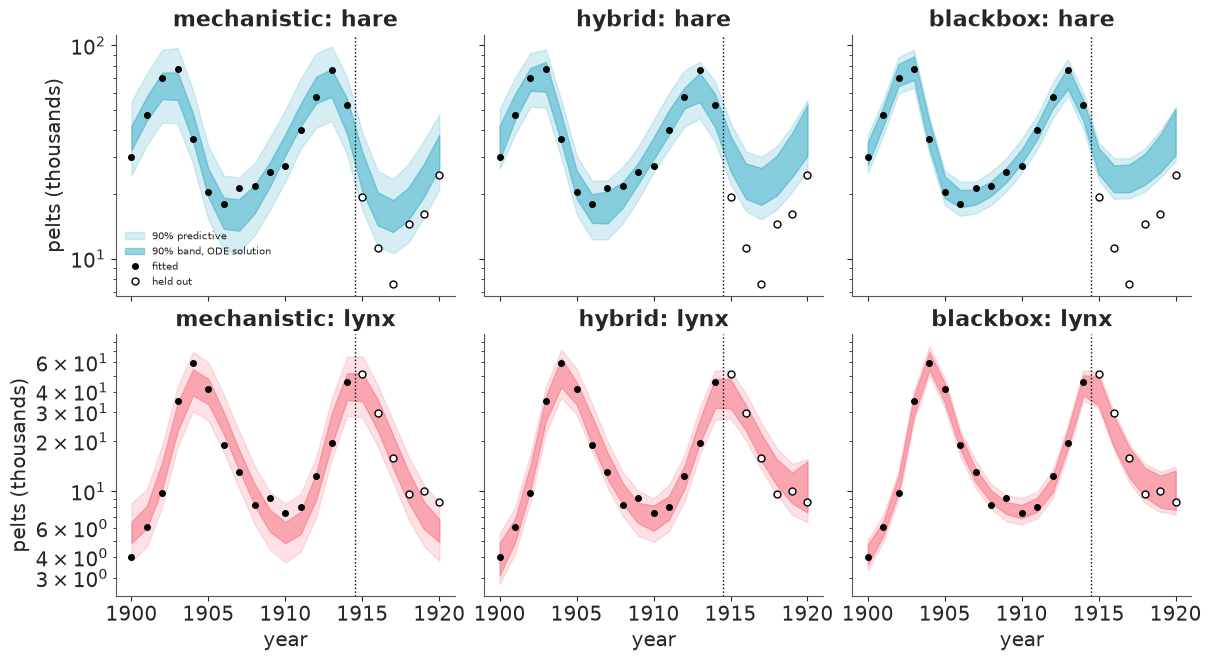

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5), sharex=True, sharey="row")
for col, (kind, (paths, predictive)) in enumerate(forecasts.items()):
    for row, species in enumerate(SPECIES):
        ax = axes[row, col]
        lo, hi = np.quantile(np.exp(predictive[:, :, row]), [0.05, 0.95], axis=0)
        ax.fill_between(YEARS, lo, hi, color=f"C{row}", alpha=0.2, label="90% predictive")
        lo, hi = np.quantile(np.exp(paths[:, :, row]), [0.05, 0.95], axis=0)
        ax.fill_between(YEARS, lo, hi, color=f"C{row}", alpha=0.5, label="90% band, ODE solution")
        ax.plot(YEARS[:N_TRAIN], obs[:N_TRAIN, row], "ko", ms=4, label="fitted")
        ax.plot(YEARS[N_TRAIN:], obs[N_TRAIN:, row], "o", mfc="white", mec="k", ms=5, label="held out")
        ax.axvline(YEARS[N_TRAIN] - 0.5, color="k", ls=":", lw=1)
        ax.set(yscale="log", title=f"{kind}: {species}")
        if row == 1:
            ax.set_xlabel("year")
    axes[0, col].set_xticks(YEARS[::5])
axes[0, 0].legend(fontsize=7, loc="lower left")
axes[0, 0].set_ylabel("pelts (thousands)")
axes[1, 0].set_ylabel("pelts (thousands)");

This is the comparison that separates them.

- **Mechanistic**: forecasts the crash of the hares and the decline of the lynx with the
  right timing; 9 of the 12 held-out observations fall inside its 90% band. Its misses are
  the hare trough of 1916-17, which was deeper than any earlier one, and the last lynx
  year. Log predictive density $-38.5$.
- **Hybrid**: $-52.3$, fourteen nats worse. Its $\sigma$ is 0.16 where the mechanistic model
  has 0.22: the network used its freedom to fit the fifteen training years more closely,
  the predictive band is narrower for it, and the hare forecast levels off far too high.
  It gets all six lynx years and *none* of the six hare years.
- **Black box**: $-71.4$, with the smallest $\sigma$ (under 0.10), the narrowest bands and
  the worst forecast - the same six hare years missed, by more, and confidently, from the
  first held-out year on.

Now the diagnostics, because two of these three fits are *not clean*, and the per-chain
table shows why for the hybrid: trajectory $\hat R$ 1.4, and one chain with $\sigma = 0.11$
while the other three have 0.18. With fifteen years of data the hybrid posterior is
**bimodal in function space**: a "mass action plus a small correction" mode, and a mode in
which the network bends the dynamics to follow the training data closely. The second has
the higher log-density (by nine nats, first column), fits better in sample and forecasts
much worse ($-73$ against about $-51$). Chains do not switch between the two, so NUTS cannot tell us their relative
weight, and the pooled score above is a three-to-one mixture by accident of
initialisation. While preparing this section I saw the same split, again one chain in
four, with a different seed; with `w_scale = 0.2` the second mode disappears and the fit
is clean and twice as fast; with sixteen training years instead of fifteen it was clean at
the one seed I tried. The prior that was comfortable with 21 years is too loose for 15.

The *ranking* does not depend on any of this: every single chain of the hybrid loses more
than ten nats to the mechanistic model, and every chain of the black box at least 28.
The hybrid's overfitting chain, at $-73$, scores like a black-box chain - which is what
it has become. The expected lesson holds, and it has a second half
that is easy to miss. **Flexibility costs you out of sample unless physics constrains
it - and the cost is invisible in sample**: the LOO table two cells up could not rank these
models, and if anything preferred the black box.

One split of one data set, twelve held-out numbers, and a system the mechanistic model
happens to describe well. Had the truth contained a strong saturating response, the
mechanistic model would have been the one forecasting confidently and wrongly, and the
hybrid the one with a chance. The point of the hybrid is not that it forecasts better. It
is that it tells you - section 7 - whether the data object to your physics.

## 10 · The natural next step: 114 years, one species

The repository also has `lynx_long`: annual lynx trappings on the Mackenzie River,
1821-1934 - five times as many years, eleven cycles, and **no hare series at all**. That is
the more typical situation in practice, and it turns the problem into a *partially
observed* system: the hare trajectory becomes a latent function that exists only through
the ODE, the likelihood touches one of the two state variables, and the prey's initial
state, growth rate and scale are identified (if at all) by the shape of the predator's
cycles. Everything in this notebook carries over mechanically - drop one column from the
likelihood, integrate 113 years instead of 20 - and everything that was hard gets harder:
the sensitivity of the trajectory to the average growth rate grows with the length of the
record (section 4), so a deterministic ODE over eleven cycles will have a spectacularly
thin posterior and a phase that drifts. I did not attempt it within this notebook's budget.
My expectation is that it needs process noise - a stochastic differential equation or a
state-space model with the hybrid right-hand side as its drift - which is also the more
honest model of an ecosystem.

## 11 · When would I actually use this?

- **Use a hybrid when you trust most of a mechanistic model and can name the term you do
  not.** Closure terms, functional responses, friction laws, reaction rates far from
  equilibrium. Formulate the network as a *correction* to your best guess for that term, so
  that "weights near zero" means "my physics was fine", and choose the weight prior by
  looking at functions, not weights (section 5).
- **Be Bayesian about it when the uncertainty of the mechanism is the result**: when someone
  will look at the learned curve and ask "is that bend real?" The answer in section 7 -
  mostly "the data cannot say" - is one no point estimate can give, and the optimised
  ensemble of section 3 would have let you over-read its wiggles.
- **Do not expect it to be cheap, and check convergence where it matters.** A network with
  15 weights and 42 data points took a hundred gradient evaluations per draw with a tight
  prior centred on the physics, and eight hundred with a loose one (section 4). Judge
  $\hat R$ and ESS on trajectories, on the
  learned function over a grid, and on the log-likelihood; never on weights. With more
  data or bigger networks, exact NUTS stops being an option and you are choosing between
  approximations whose function-space behaviour you should test on a small case first
  (section 6).
- **Do not use it to forecast outside the data unless the physics carries the forecast.**
  Section 9: every model fits the past; they are ranked in the future by how much they
  assume. Flexibility is not free, and in-sample criteria such as LOO do not reveal the
  cost, because they never ask the model to leave the orbit it was trained on.
- **If you have no physics at all, a neural ODE is rarely the right first model** for 21
  points. A Gaussian process on the vector field, or plain autoregression, will give similar
  forecasts with a posterior you can actually compute.

### Try it yourself

1. **Turn the knob.** Refit the hybrid with `w_scale = 0.1` and `w_scale = 0.5` (allow the
   second several minutes and raise `maxdepth` to 10). How do the leapfrog steps per draw,
   the elasticity intervals of section 7 and the forecast score of section 9 move? At what
   scale does the 15-year fit stop being trustworthy?
2. **A monotone, signed correction.** Ecology says more than "roughly mass action":
   predation per lynx should not *decrease* when hares become more abundant. Build that in -
   for example $c_k = -\text{softplus}(\text{mlp}_k)$ for a saturating response, or weights
   constrained to be positive through `pm.HalfNormal` and an increasing activation - and see
   what it does to the width of the bands in section 7 and to the forecast.
3. **Sparsity instead of shrinkage.** Replace the `Normal(0, 0.3)` weight prior with a
   regularised horseshoe on the *output* weights `W2`, so that whole hidden units can switch
   off. Does the posterior prefer "no correction at all" for one of the two terms? (Expect
   funnel geometry on top of everything in section 4: non-centre it, and check function
   space.) Then try the partially observed `lynx_long` problem of section 10 if you have an
   afternoon.